In [18]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
df_context = pd.read_csv("fitlife_context.csv")
df_members = pd.read_csv("fitlife_members.csv")

In [4]:
df_members

,member_id,month,center,plan,price_paid,signup_date,acquisition_channel,tenure_months,visits_this_month,group_classes_attended,uses_app,has_personal_trainer,cost_to_serve,status,churn_reason
0,M0001,2022-01,westfield,premium,44.1,2020-07-27,corporate,18,19,6,True,False,26.02,active,NaN
1,M0001,2022-02,westfield,premium,44.1,2020-07-27,corporate,19,18,4,True,False,22.39,active,NaN
2,M0001,2022-03,westfield,premium,44.1,2020-07-27,corporate,20,15,5,True,False,21.29,active,NaN
3,M0001,2022-04,westfield,premium,44.1,2020-07-27,corporate,21,21,4,True,False,24.83,active,NaN
4,M0001,2022-05,westfield,premium,44.1,2020-07-27,corporate,22,20,5,True,False,25.45,active,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16329,M0936,2024-12,downtown,basic,26.1,2024-12-11,referral,0,0,0,False,False,1.50,active,NaN
16330,M0937,2024-12,westfield,premium,49.0,2024-12-27,walk_in,0,5,5,True,False,14.40,active,NaN
16331,M0938,2024-12,eastpark,family,62.1,2024-12-08,corporate,0,5,3,False,False,13.40,active,NaN
16332,M0939,2024-12,downtown,basic,26.1,2024-12-08,referral,0,6,1,False,False,6.81,active,NaN


In [5]:
df_context

,month,competitor_lowcost_price,campaign_active,service_incident,monthly_fixed_costs,avg_occupancy_rate,acquisition_cost_avg
0,2022-01,25.0,january_promo,NaN,16699,0.55,54.4
1,2022-02,25.0,NaN,NaN,16878,0.49,31.6
2,2022-03,25.0,NaN,NaN,15846,0.44,36.0
3,2022-04,25.0,NaN,NaN,16366,0.38,39.7
4,2022-05,25.0,NaN,NaN,16465,0.39,31.8
5,2022-06,25.0,summer_body,NaN,15346,0.30,30.2
6,2022-07,23.0,NaN,app_outage,15545,0.30,30.9
7,2022-08,23.0,NaN,NaN,15311,0.30,28.9
8,2022-09,23.0,back_to_gym,NaN,16164,0.45,41.2
9,2022-10,23.0,NaN,NaN,16211,0.44,30.5


# Salud Financiera

## P1. Margen por miembro y su evolución mensual

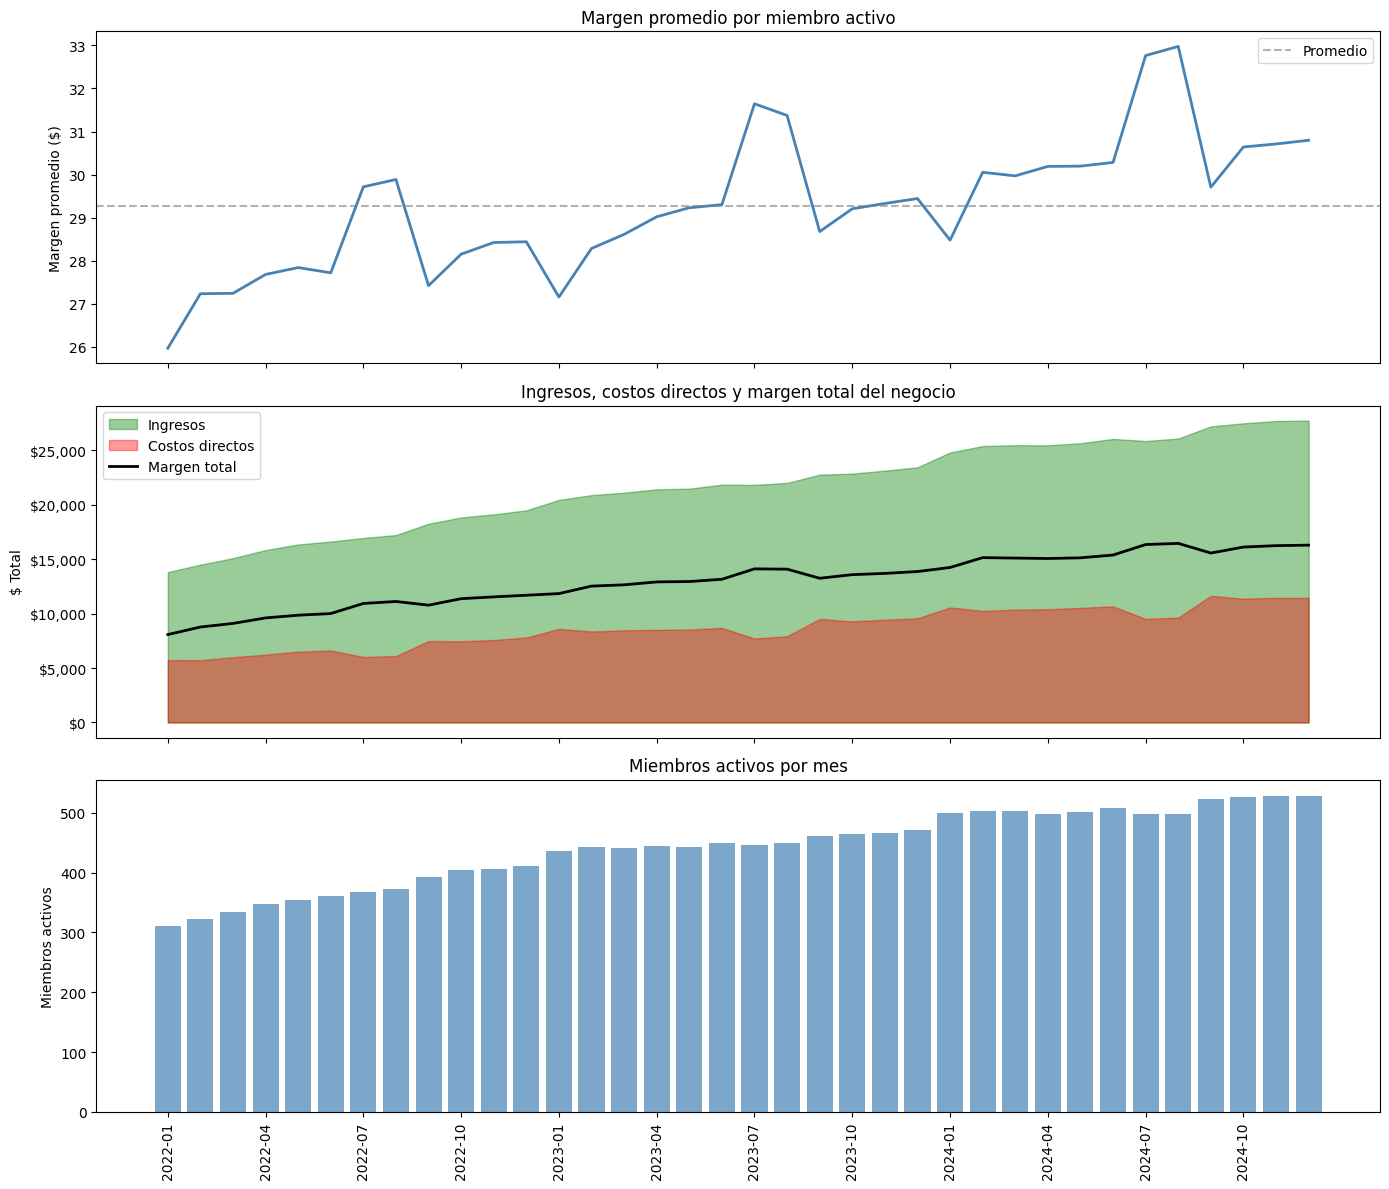


Margen promedio por miembro: $29.27
Margen total promedio mensual: $13,016
Rango de miembros activos: 311 – 529


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Margen unitario por fila
df_members['margin'] = df_members['price_paid'] - df_members['cost_to_serve']
df_members['margin_pct'] = df_members['margin'] / df_members['price_paid'] * 100

# Agregar por mes: margen promedio por miembro y margen total del negocio
monthly_margin = (
    df_members[df_members['status'] == 'active']
    .groupby('month')
    .agg(
        avg_margin_per_member=('margin', 'mean'),
        total_revenue=('price_paid', 'sum'),
        total_cost=('cost_to_serve', 'sum'),
        n_active=('member_id', 'count')
    )
    .reset_index()
)
monthly_margin['total_margin'] = monthly_margin['total_revenue'] - monthly_margin['total_cost']

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: margen promedio por miembro
axes[0].plot(monthly_margin['month'], monthly_margin['avg_margin_per_member'], color='steelblue', linewidth=2)
axes[0].axhline(monthly_margin['avg_margin_per_member'].mean(), color='gray', linestyle='--', alpha=0.6, label='Promedio')
axes[0].set_ylabel('Margen promedio ($)')
axes[0].set_title('Margen promedio por miembro activo')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Panel 2: ingresos, costos y margen total
axes[1].fill_between(monthly_margin['month'], monthly_margin['total_revenue'], label='Ingresos', alpha=0.4, color='green')
axes[1].fill_between(monthly_margin['month'], monthly_margin['total_cost'], label='Costos directos', alpha=0.4, color='red')
axes[1].plot(monthly_margin['month'], monthly_margin['total_margin'], color='black', linewidth=2, label='Margen total')
axes[1].set_ylabel('$ Total')
axes[1].set_title('Ingresos, costos directos y margen total del negocio')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=45)

# Panel 3: número de miembros activos
axes[2].bar(monthly_margin['month'], monthly_margin['n_active'], color='steelblue', alpha=0.7)
axes[2].set_ylabel('Miembros activos')
axes[2].set_title('Miembros activos por mes')
axes[2].tick_params(axis='x', rotation=90)

# Mostrar solo algunos ticks en eje x para no saturar
tick_positions = range(0, len(monthly_margin), 3)
for ax in axes:
    ax.set_xticks([monthly_margin['month'].iloc[i] for i in tick_positions])

plt.tight_layout()
plt.show()

print(f"\nMargen promedio por miembro: ${monthly_margin['avg_margin_per_member'].mean():.2f}")
print(f"Margen total promedio mensual: ${monthly_margin['total_margin'].mean():,.0f}")
print(f"Rango de miembros activos: {monthly_margin['n_active'].min()} – {monthly_margin['n_active'].max()}")


## P2. Ingreso neto y margen por plan

=== Margen por plan ===
   plan  avg_price  avg_cost  avg_margin  avg_margin_pct  total_revenue  total_margin  n_records
 family  67.690975 20.411749   47.279226       69.804404       338251.8     236254.29       4997
premium  47.923205 25.059556   22.863649       47.580984       323625.4     154398.22       6753
  basic  28.380110  9.703870   18.676240       65.761384       118430.2      77935.95       4173


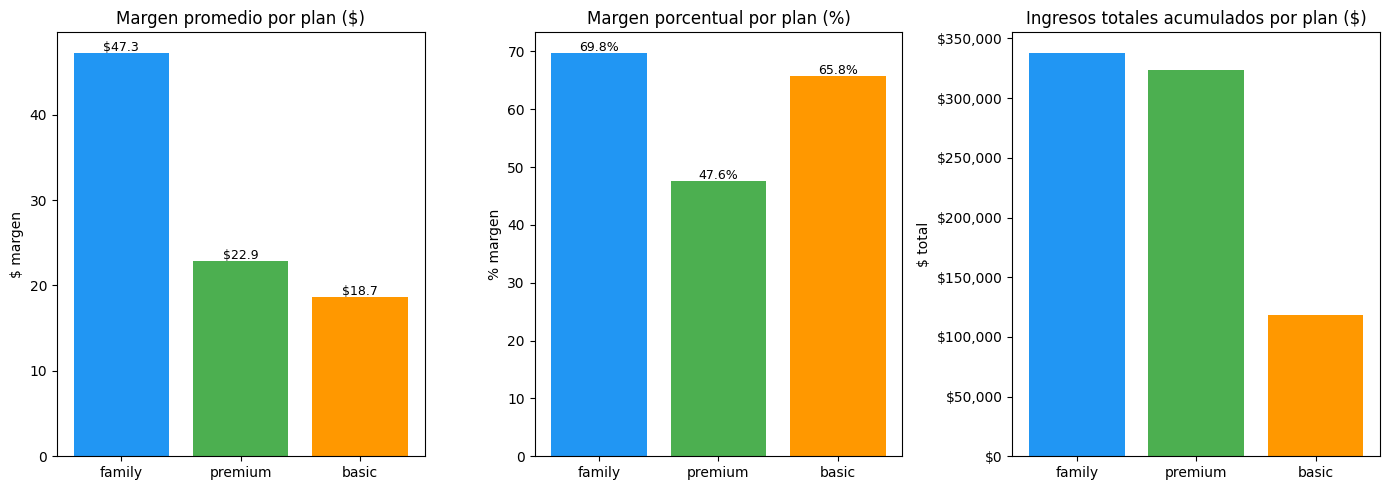

In [7]:
plan_summary = (
    df_members[df_members['status'] == 'active']
    .groupby('plan')
    .agg(
        avg_price=('price_paid', 'mean'),
        avg_cost=('cost_to_serve', 'mean'),
        avg_margin=('margin', 'mean'),
        avg_margin_pct=('margin_pct', 'mean'),
        total_revenue=('price_paid', 'sum'),
        total_margin=('margin', 'sum'),
        n_records=('member_id', 'count')
    )
    .reset_index()
    .sort_values('avg_margin', ascending=False)
)

print("=== Margen por plan ===")
print(plan_summary[['plan', 'avg_price', 'avg_cost', 'avg_margin', 'avg_margin_pct', 'total_revenue', 'total_margin', 'n_records']]
      .to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Margen absoluto por plan
axes[0].bar(plan_summary['plan'], plan_summary['avg_margin'], color=colors[:len(plan_summary)])
axes[0].set_title('Margen promedio por plan ($)')
axes[0].set_ylabel('$ margen')
for i, v in enumerate(plan_summary['avg_margin']):
    axes[0].text(i, v + 0.2, f'${v:.1f}', ha='center', fontsize=9)

# Margen porcentual
axes[1].bar(plan_summary['plan'], plan_summary['avg_margin_pct'], color=colors[:len(plan_summary)])
axes[1].set_title('Margen porcentual por plan (%)')
axes[1].set_ylabel('% margen')
for i, v in enumerate(plan_summary['avg_margin_pct']):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# Ingresos totales generados (importancia en el portfolio)
axes[2].bar(plan_summary['plan'], plan_summary['total_revenue'], color=colors[:len(plan_summary)])
axes[2].set_title('Ingresos totales acumulados por plan ($)')
axes[2].set_ylabel('$ total')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


## P3. Precio FitLife vs competidor lowcost a lo largo del tiempo

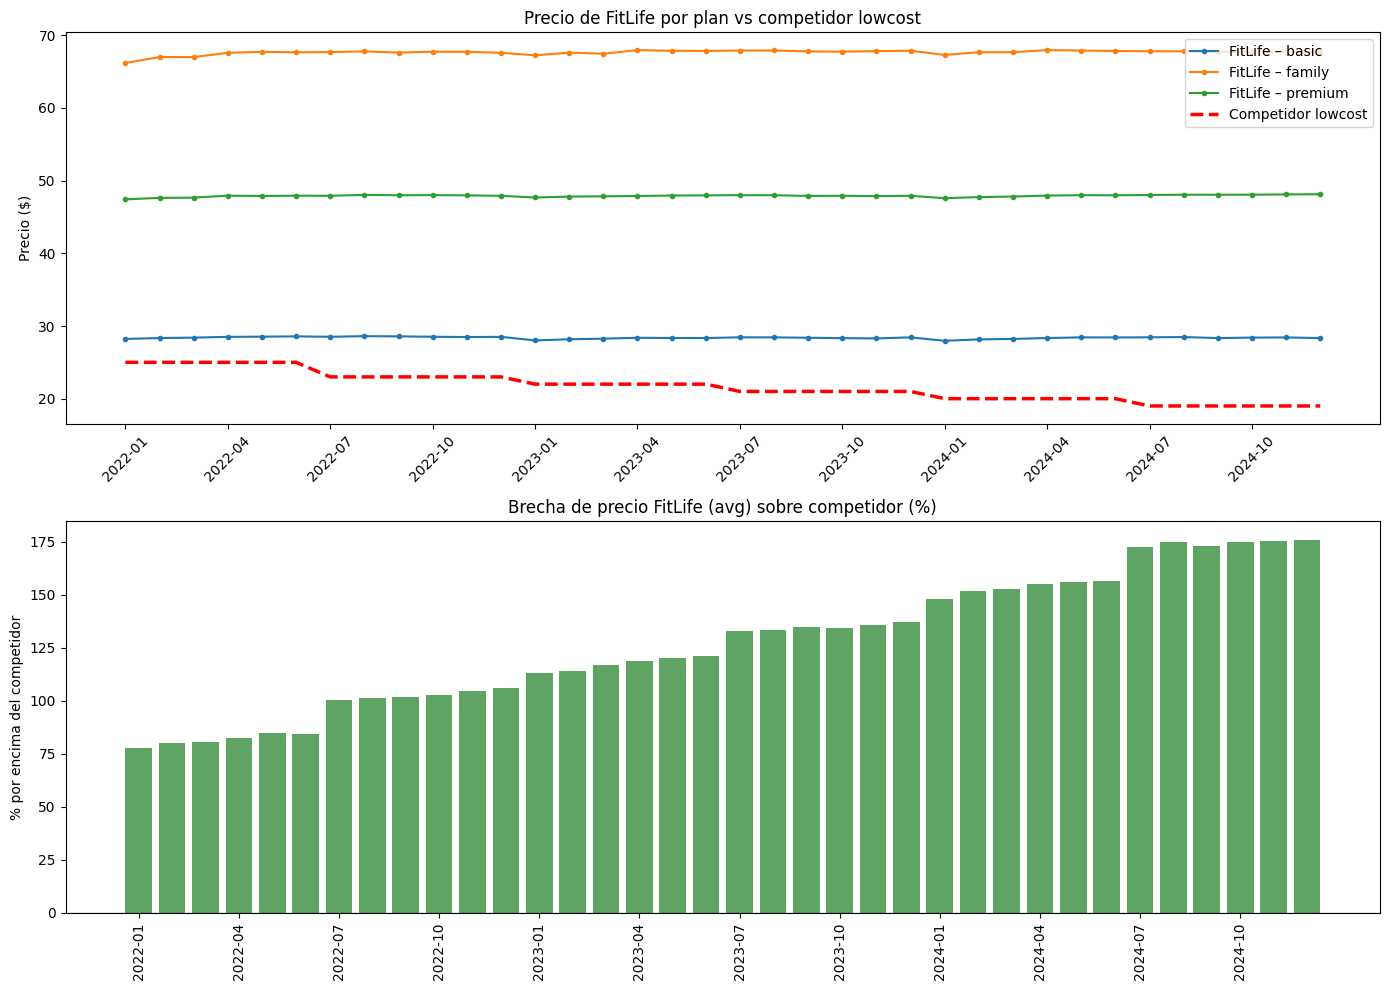


Brecha promedio FitLife vs competidor: +127.5%
Evolución brecha: 77.7% (2022-01) → 175.9% (2024-12)


In [8]:
# Precio promedio de FitLife por mes (todos los planes activos)
fitlife_price = (
    df_members[df_members['status'] == 'active']
    .groupby('month')['price_paid']
    .mean()
    .reset_index()
    .rename(columns={'price_paid': 'fitlife_avg_price'})
)

# Precio por plan por mes
fitlife_price_plan = (
    df_members[df_members['status'] == 'active']
    .groupby(['month', 'plan'])['price_paid']
    .mean()
    .reset_index()
)

# Merge con contexto para tener precio competidor
price_vs_comp = fitlife_price.merge(df_context[['month', 'competitor_lowcost_price']], on='month')
price_plan_vs_comp = fitlife_price_plan.merge(df_context[['month', 'competitor_lowcost_price']], on='month')

# Brecha de precio
price_vs_comp['price_gap'] = price_vs_comp['fitlife_avg_price'] - price_vs_comp['competitor_lowcost_price']
price_vs_comp['gap_pct'] = price_vs_comp['price_gap'] / price_vs_comp['competitor_lowcost_price'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Panel 1: precio por plan vs competidor
for plan in fitlife_price_plan['plan'].unique():
    subset = price_plan_vs_comp[price_plan_vs_comp['plan'] == plan]
    axes[0].plot(subset['month'], subset['price_paid'], marker='o', markersize=3, label=f'FitLife – {plan}')
axes[0].plot(price_vs_comp['month'], price_vs_comp['competitor_lowcost_price'],
             color='red', linewidth=2.5, linestyle='--', label='Competidor lowcost')
axes[0].set_title('Precio de FitLife por plan vs competidor lowcost')
axes[0].set_ylabel('Precio ($)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xticks([price_vs_comp['month'].iloc[i] for i in range(0, len(price_vs_comp), 3)])

# Panel 2: brecha de precio promedio (FitLife avg vs competidor)
bar_colors = ['#d32f2f' if v < 0 else '#388e3c' for v in price_vs_comp['gap_pct']]
axes[1].bar(price_vs_comp['month'], price_vs_comp['gap_pct'], color=bar_colors, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Brecha de precio FitLife (avg) sobre competidor (%)')
axes[1].set_ylabel('% por encima del competidor')
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_xticks([price_vs_comp['month'].iloc[i] for i in range(0, len(price_vs_comp), 3)])

plt.tight_layout()
plt.show()

print(f"\nBrecha promedio FitLife vs competidor: +{price_vs_comp['gap_pct'].mean():.1f}%")
print(f"Evolución brecha: {price_vs_comp['gap_pct'].iloc[0]:.1f}% (2022-01) → {price_vs_comp['gap_pct'].iloc[-1]:.1f}% (2024-12)")


## P4. Costos fijos mensuales

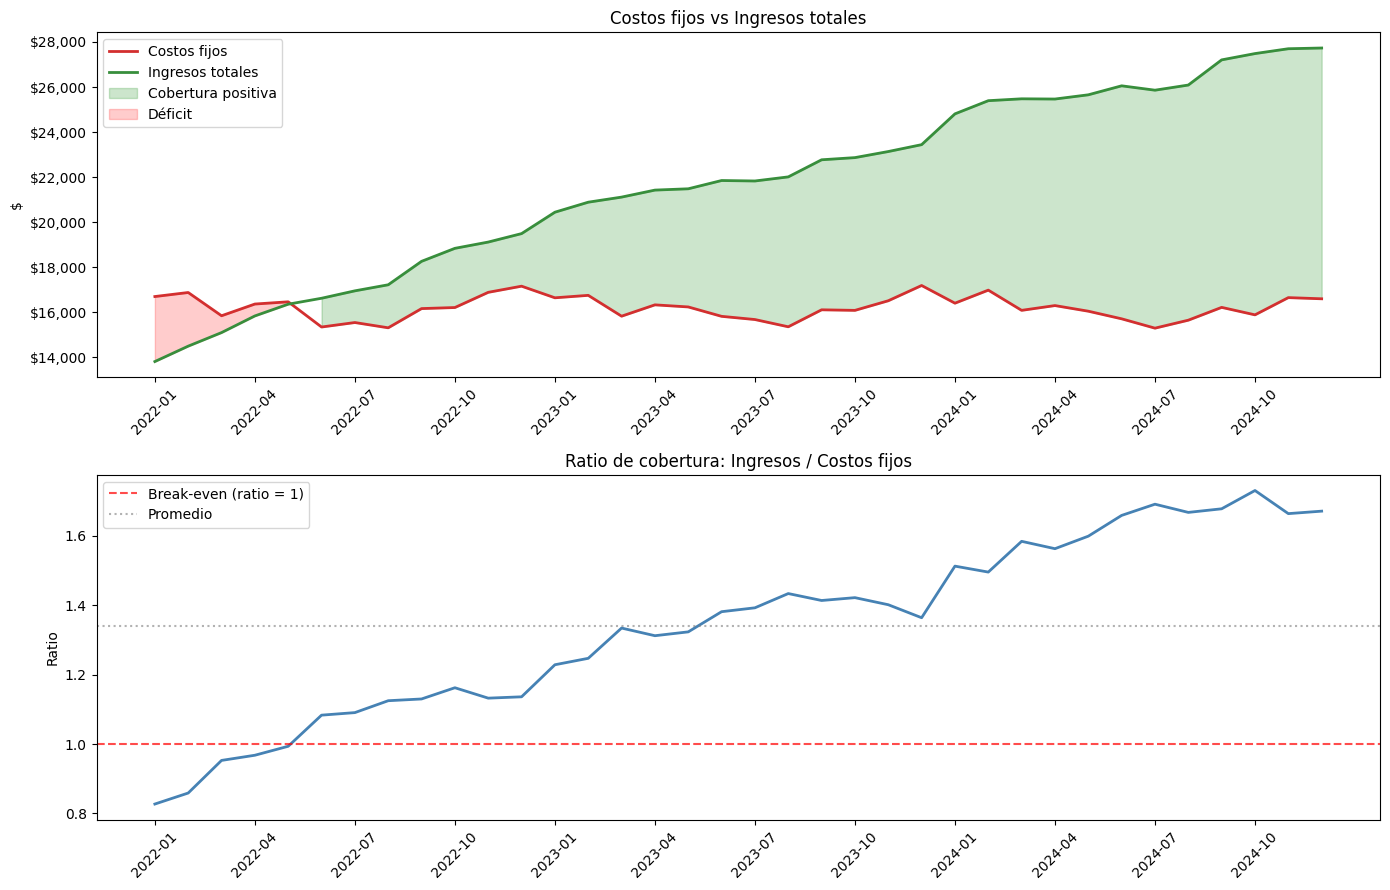


Costo fijo promedio mensual: $16,201
Costo fijo mínimo: $15,295  |  máximo: $17,189
Ratio de cobertura promedio: 1.34x
Meses por debajo de break-even: 5


In [9]:
# Ingresos totales por mes para comparar contra costos fijos
monthly_revenue = (
    df_members[df_members['status'] == 'active']
    .groupby('month')['price_paid']
    .sum()
    .reset_index()
    .rename(columns={'price_paid': 'total_revenue'})
)

fixed_vs_rev = df_context[['month', 'monthly_fixed_costs']].merge(monthly_revenue, on='month')
fixed_vs_rev['coverage_ratio'] = fixed_vs_rev['total_revenue'] / fixed_vs_rev['monthly_fixed_costs']

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: costos fijos vs ingresos totales
axes[0].plot(fixed_vs_rev['month'], fixed_vs_rev['monthly_fixed_costs'],
             color='#d32f2f', linewidth=2, label='Costos fijos')
axes[0].plot(fixed_vs_rev['month'], fixed_vs_rev['total_revenue'],
             color='#388e3c', linewidth=2, label='Ingresos totales')
axes[0].fill_between(fixed_vs_rev['month'],
                     fixed_vs_rev['monthly_fixed_costs'],
                     fixed_vs_rev['total_revenue'],
                     where=fixed_vs_rev['total_revenue'] >= fixed_vs_rev['monthly_fixed_costs'],
                     alpha=0.2, color='green', label='Cobertura positiva')
axes[0].fill_between(fixed_vs_rev['month'],
                     fixed_vs_rev['monthly_fixed_costs'],
                     fixed_vs_rev['total_revenue'],
                     where=fixed_vs_rev['total_revenue'] < fixed_vs_rev['monthly_fixed_costs'],
                     alpha=0.2, color='red', label='Déficit')
axes[0].set_title('Costos fijos vs Ingresos totales')
axes[0].set_ylabel('$')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xticks([fixed_vs_rev['month'].iloc[i] for i in range(0, len(fixed_vs_rev), 3)])

# Panel 2: ratio de cobertura (ingresos / costos fijos)
axes[1].plot(fixed_vs_rev['month'], fixed_vs_rev['coverage_ratio'], color='steelblue', linewidth=2)
axes[1].axhline(1, color='red', linestyle='--', alpha=0.7, label='Break-even (ratio = 1)')
axes[1].axhline(fixed_vs_rev['coverage_ratio'].mean(), color='gray', linestyle=':', alpha=0.6, label='Promedio')
axes[1].set_title('Ratio de cobertura: Ingresos / Costos fijos')
axes[1].set_ylabel('Ratio')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xticks([fixed_vs_rev['month'].iloc[i] for i in range(0, len(fixed_vs_rev), 3)])

plt.tight_layout()
plt.show()

print(f"\nCosto fijo promedio mensual: ${df_context['monthly_fixed_costs'].mean():,.0f}")
print(f"Costo fijo mínimo: ${df_context['monthly_fixed_costs'].min():,.0f}  |  máximo: ${df_context['monthly_fixed_costs'].max():,.0f}")
print(f"Ratio de cobertura promedio: {fixed_vs_rev['coverage_ratio'].mean():.2f}x")
print(f"Meses por debajo de break-even: {(fixed_vs_rev['coverage_ratio'] < 1).sum()}")


## P5. CAC por canal y tiempo de recuperación

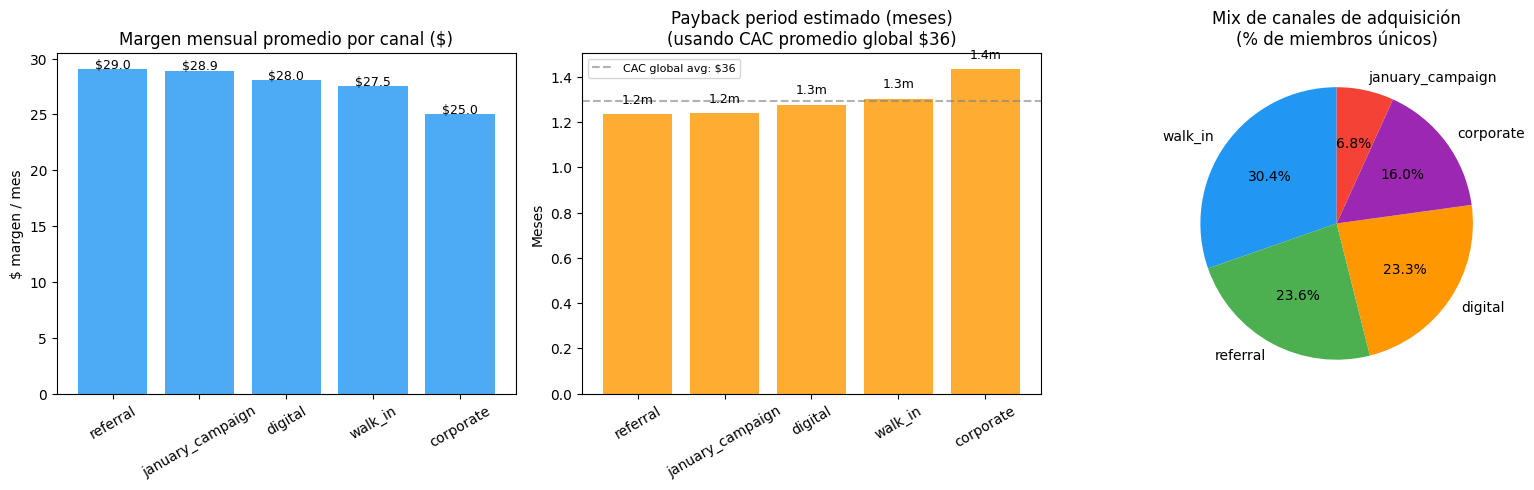

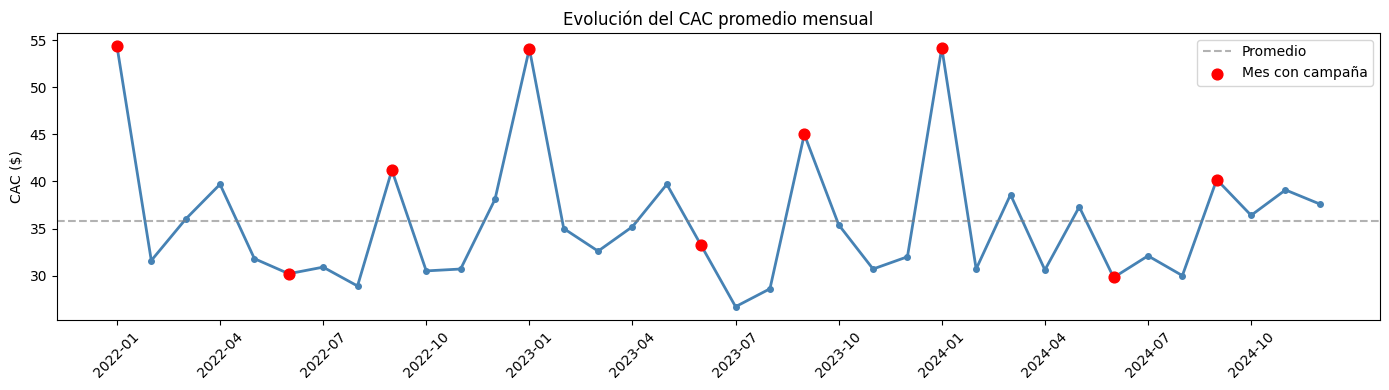


CAC promedio global: $35.8
CAC máximo (meses de campaña enero): $54.4
acquisition_channel  avg_monthly_margin  payback_months  n_members
          corporate           24.999836        1.432009        149
            digital           28.045916        1.276478        216
   january_campaign           28.925856        1.237647         63
           referral           29.039825        1.232790        219
            walk_in           27.519861        1.300879        282


In [10]:
# CAC promedio global del contexto
cac_avg = df_context['acquisition_cost_avg'].mean()

# Margen promedio por miembro por canal (para calcular payback)
channel_margin = (
    df_members[df_members['status'] == 'active']
    .groupby(['member_id', 'acquisition_channel'])
    .agg(avg_monthly_margin=('margin', 'mean'))
    .reset_index()
    .groupby('acquisition_channel')
    .agg(
        avg_monthly_margin=('avg_monthly_margin', 'mean'),
        n_members=('member_id', 'nunique')
    )
    .reset_index()
)

# Payback period = CAC / margen mensual promedio
channel_margin['payback_months'] = cac_avg / channel_margin['avg_monthly_margin']

# Mix de canales
channel_mix = (
    df_members[df_members['status'] == 'active']
    .drop_duplicates(subset=['member_id'])
    ['acquisition_channel']
    .value_counts(normalize=True) * 100
).reset_index()
channel_mix.columns = ['acquisition_channel', 'pct_members']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Margen mensual promedio por canal
channel_margin_sorted = channel_margin.sort_values('avg_monthly_margin', ascending=False)
axes[0].bar(channel_margin_sorted['acquisition_channel'], channel_margin_sorted['avg_monthly_margin'],
            color='#2196F3', alpha=0.8)
axes[0].set_title('Margen mensual promedio por canal ($)')
axes[0].set_ylabel('$ margen / mes')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(channel_margin_sorted['avg_monthly_margin']):
    axes[0].text(i, v + 0.1, f'${v:.1f}', ha='center', fontsize=9)

# Payback period
channel_margin_sorted2 = channel_margin.sort_values('payback_months')
axes[1].bar(channel_margin_sorted2['acquisition_channel'], channel_margin_sorted2['payback_months'],
            color='#FF9800', alpha=0.8)
axes[1].axhline(cac_avg / channel_margin['avg_monthly_margin'].mean(),
                color='gray', linestyle='--', alpha=0.6, label=f'CAC global avg: ${cac_avg:.0f}')
axes[1].set_title(f'Payback period estimado (meses)\n(usando CAC promedio global ${cac_avg:.0f})')
axes[1].set_ylabel('Meses')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8)
for i, v in enumerate(channel_margin_sorted2['payback_months']):
    axes[1].text(i, v + 0.05, f'{v:.1f}m', ha='center', fontsize=9)

# Mix de canales (pie)
axes[2].pie(channel_mix['pct_members'], labels=channel_mix['acquisition_channel'],
            autopct='%1.1f%%', startangle=90, colors=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336'])
axes[2].set_title('Mix de canales de adquisición\n(% de miembros únicos)')

plt.tight_layout()
plt.show()

# Evolución del CAC en el tiempo
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_context['month'], df_context['acquisition_cost_avg'], color='steelblue', linewidth=2, marker='o', markersize=4)
ax.axhline(df_context['acquisition_cost_avg'].mean(), color='gray', linestyle='--', alpha=0.6, label='Promedio')
# Marcar meses de campaña
campaign_months = df_context[df_context['campaign_active'].notna()]
ax.scatter(campaign_months['month'], campaign_months['acquisition_cost_avg'],
           color='red', zorder=5, s=60, label='Mes con campaña')
ax.set_title('Evolución del CAC promedio mensual')
ax.set_ylabel('CAC ($)')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.set_xticks([df_context['month'].iloc[i] for i in range(0, len(df_context), 3)])
plt.tight_layout()
plt.show()

print(f"\nCAC promedio global: ${cac_avg:.1f}")
print(f"CAC máximo (meses de campaña enero): ${campaign_months['acquisition_cost_avg'].max():.1f}")
print(channel_margin[['acquisition_channel', 'avg_monthly_margin', 'payback_months', 'n_members']].to_string(index=False))


# Churn y Retención

## P6. Tasa de churn mensual

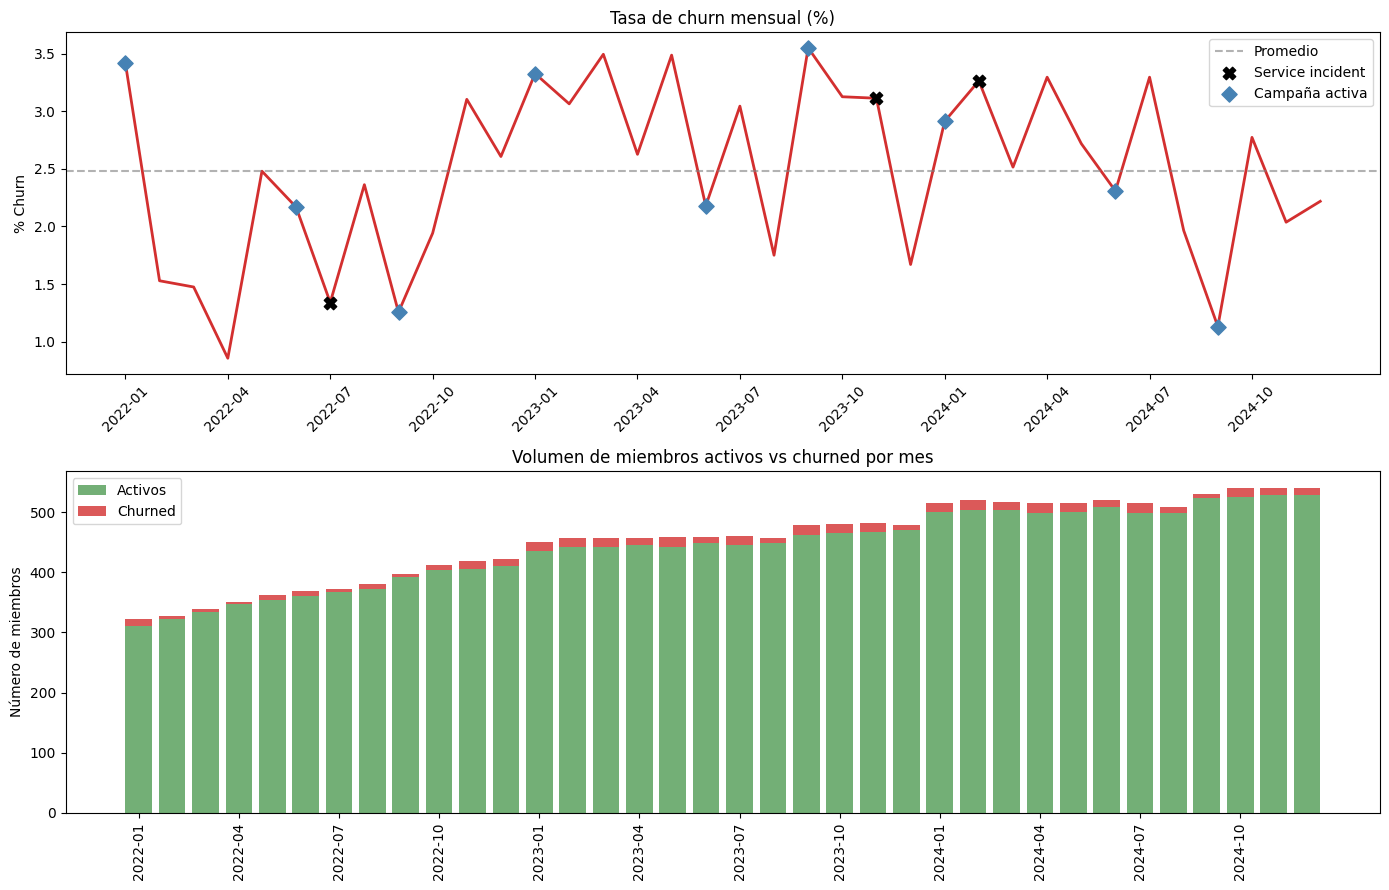


Tasa de churn promedio: 2.48%
Mes con mayor churn: 2023-09 (3.5%)
Total churned (histórico): 411


In [11]:
# Calcular churn por mes: filas con status == 'churned'
churn_by_month = (
    df_members.groupby('month')
    .agg(
        total=('member_id', 'count'),
        churned=('status', lambda x: (x == 'churned').sum())
    )
    .reset_index()
)
churn_by_month['churn_rate'] = churn_by_month['churned'] / churn_by_month['total'] * 100

# Merge con contexto para marcar incidentes y campañas
churn_ctx = churn_by_month.merge(df_context[['month', 'campaign_active', 'service_incident']], on='month')

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: tasa de churn mensual
axes[0].plot(churn_ctx['month'], churn_ctx['churn_rate'], color='#d32f2f', linewidth=2)
axes[0].axhline(churn_ctx['churn_rate'].mean(), color='gray', linestyle='--', alpha=0.6, label='Promedio')
# Marcar incidentes
incidents = churn_ctx[churn_ctx['service_incident'].notna()]
axes[0].scatter(incidents['month'], incidents['churn_rate'], color='black', zorder=5, s=80, marker='X', label='Service incident')
# Marcar campañas
campaigns = churn_ctx[churn_ctx['campaign_active'].notna()]
axes[0].scatter(campaigns['month'], campaigns['churn_rate'], color='steelblue', zorder=5, s=60, marker='D', label='Campaña activa')
axes[0].set_title('Tasa de churn mensual (%)')
axes[0].set_ylabel('% Churn')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xticks([churn_ctx['month'].iloc[i] for i in range(0, len(churn_ctx), 3)])

# Panel 2: volumen absoluto — activos vs churned
axes[1].bar(churn_ctx['month'], churn_ctx['total'] - churn_ctx['churned'], label='Activos', color='#388e3c', alpha=0.7)
axes[1].bar(churn_ctx['month'], churn_ctx['churned'], bottom=churn_ctx['total'] - churn_ctx['churned'],
            label='Churned', color='#d32f2f', alpha=0.8)
axes[1].set_title('Volumen de miembros activos vs churned por mes')
axes[1].set_ylabel('Número de miembros')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_xticks([churn_ctx['month'].iloc[i] for i in range(0, len(churn_ctx), 3)])

plt.tight_layout()
plt.show()

print(f"\nTasa de churn promedio: {churn_ctx['churn_rate'].mean():.2f}%")
print(f"Mes con mayor churn: {churn_ctx.loc[churn_ctx['churn_rate'].idxmax(), 'month']} ({churn_ctx['churn_rate'].max():.1f}%)")
print(f"Total churned (histórico): {churn_ctx['churned'].sum()}")


## P7. Razones de churn más frecuentes

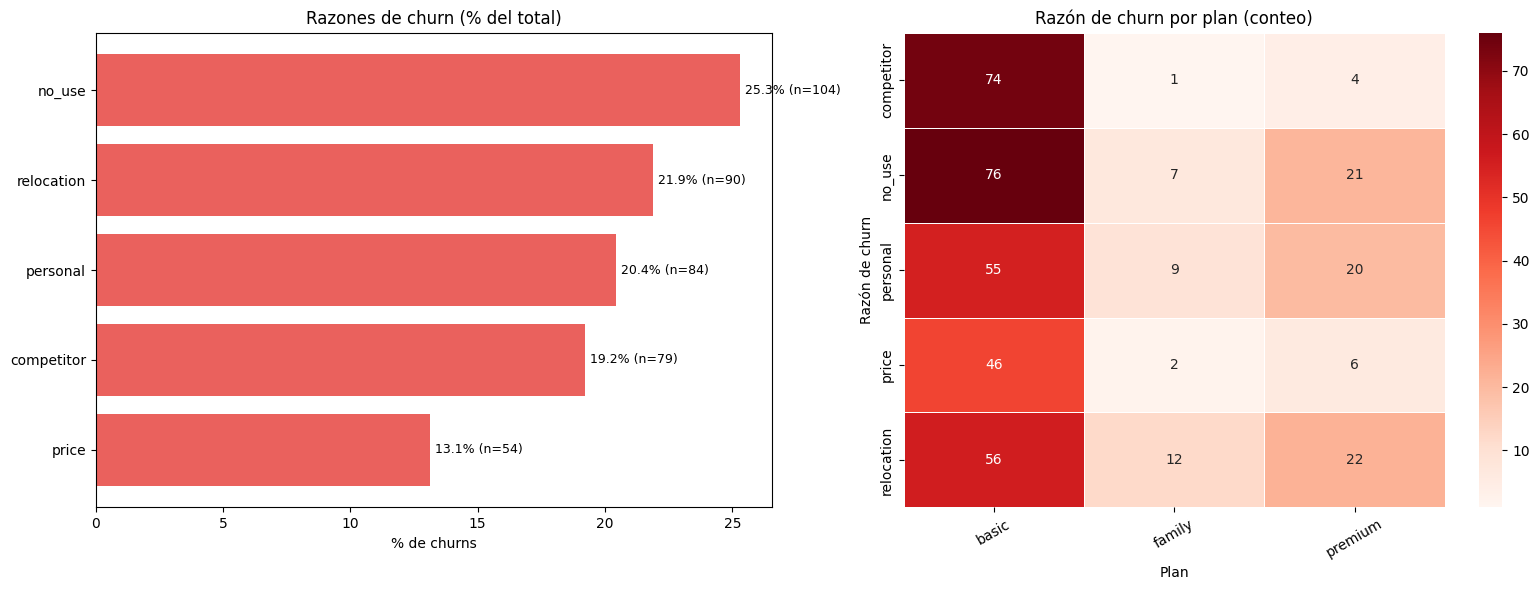


=== Distribución de razones de churn ===
churn_reason  count       pct
      no_use    104 25.304136
  relocation     90 21.897810
    personal     84 20.437956
  competitor     79 19.221411
       price     54 13.138686


In [12]:
churned_df = df_members[df_members['status'] == 'churned'].copy()

# Frecuencia de razones de churn
churn_reasons = churned_df['churn_reason'].value_counts().reset_index()
churn_reasons.columns = ['churn_reason', 'count']
churn_reasons['pct'] = churn_reasons['count'] / churn_reasons['count'].sum() * 100

# Razón de churn por plan
churn_by_plan_reason = (
    churned_df.groupby(['plan', 'churn_reason'])
    .size()
    .reset_index(name='count')
)
churn_pivot = churn_by_plan_reason.pivot(index='churn_reason', columns='plan', values='count').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras horizontales de razones
axes[0].barh(churn_reasons['churn_reason'], churn_reasons['pct'], color='#e53935', alpha=0.8)
axes[0].set_title('Razones de churn (% del total)')
axes[0].set_xlabel('% de churns')
for i, (v, c) in enumerate(zip(churn_reasons['pct'], churn_reasons['count'])):
    axes[0].text(v + 0.2, i, f'{v:.1f}% (n={c})', va='center', fontsize=9)
axes[0].invert_yaxis()

# Heatmap de razón × plan
import seaborn as sns
sns.heatmap(churn_pivot, annot=True, fmt='.0f', cmap='Reds', ax=axes[1], linewidths=0.5)
axes[1].set_title('Razón de churn por plan (conteo)')
axes[1].set_xlabel('Plan')
axes[1].set_ylabel('Razón de churn')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\n=== Distribución de razones de churn ===")
print(churn_reasons.to_string(index=False))


## P8. Churn según uso de app y entrenador personal

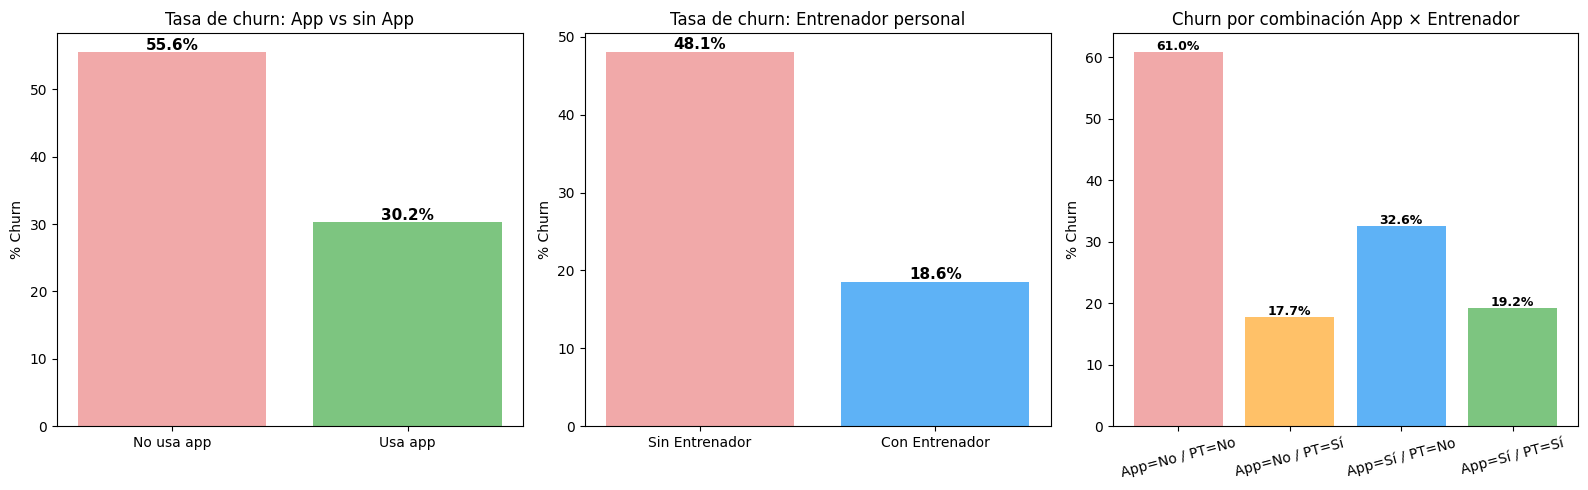

In [13]:
# Tomar último registro por miembro (el que define si churned o active)
last_record = df_members.sort_values('month').groupby('member_id').last().reset_index()

def churn_rate_by(col):
    return (
        last_record.groupby(col)['status']
        .apply(lambda x: (x == 'churned').sum() / len(x) * 100)
        .reset_index(name='churn_rate')
    )

cr_app = churn_rate_by('uses_app')
cr_pt = churn_rate_by('has_personal_trainer')
cr_app_pt = last_record.groupby(['uses_app', 'has_personal_trainer'])['status'].apply(
    lambda x: (x == 'churned').sum() / len(x) * 100
).reset_index(name='churn_rate')
cr_app_pt['label'] = cr_app_pt.apply(
    lambda r: f"App={'Sí' if r['uses_app'] else 'No'} / PT={'Sí' if r['has_personal_trainer'] else 'No'}", axis=1
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# App vs no app
app_labels = ['No usa app', 'Usa app']
app_colors = ['#ef9a9a', '#66bb6a']
bars = axes[0].bar(app_labels, cr_app['churn_rate'], color=app_colors, alpha=0.85)
axes[0].set_title('Tasa de churn: App vs sin App')
axes[0].set_ylabel('% Churn')
for bar, v in zip(bars, cr_app['churn_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# PT vs no PT
pt_labels = ['Sin Entrenador', 'Con Entrenador']
bars = axes[1].bar(pt_labels, cr_pt['churn_rate'], color=['#ef9a9a', '#42a5f5'], alpha=0.85)
axes[1].set_title('Tasa de churn: Entrenador personal')
axes[1].set_ylabel('% Churn')
for bar, v in zip(bars, cr_pt['churn_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Combinación app × PT
bars = axes[2].bar(cr_app_pt['label'], cr_app_pt['churn_rate'],
                   color=['#ef9a9a','#ffb74d','#42a5f5','#66bb6a'], alpha=0.85)
axes[2].set_title('Churn por combinación App × Entrenador')
axes[2].set_ylabel('% Churn')
axes[2].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, cr_app_pt['churn_rate']):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## P9. Churn por tenure — ¿dónde se concentra la pérdida?

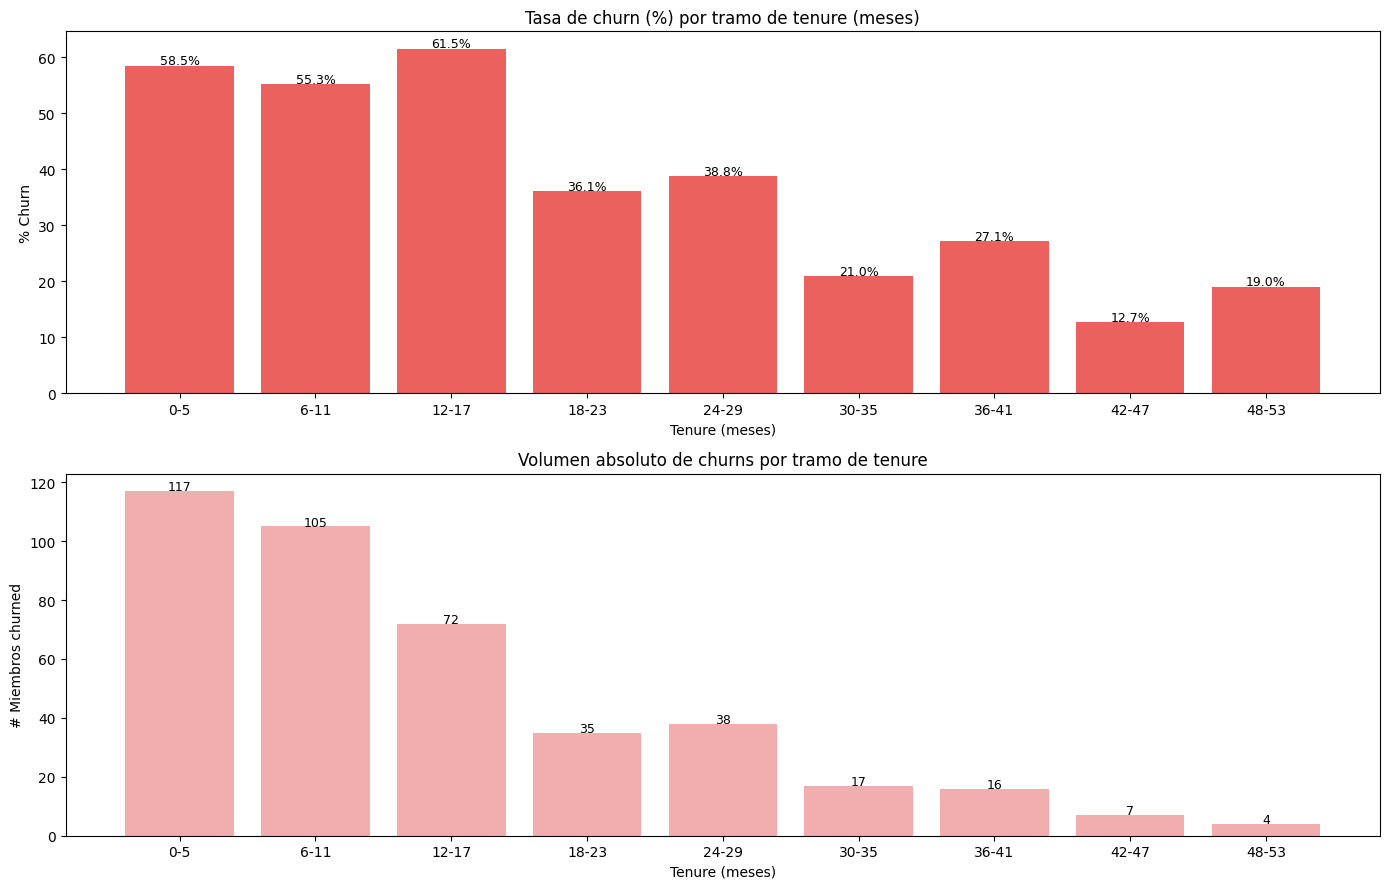

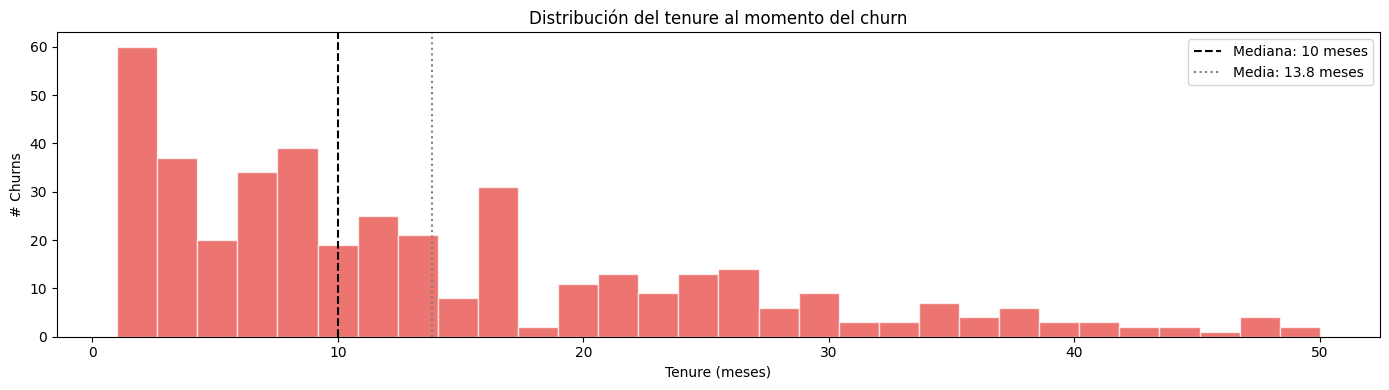


Tenure mediana al churn: 10 meses
Tenure media al churn: 13.8 meses
% churns en primeros 6 meses: 28.5%
% churns en primeros 12 meses: 54.0%


In [14]:
# Usar el último registro de cada miembro para ver en qué tenure churnan
churn_tenure = last_record[last_record['status'] == 'churned']['tenure_months']

# Agrupar en bins de 6 meses para legibilidad
bins = list(range(0, churn_tenure.max() + 7, 6))
labels = [f'{b}-{b+5}' for b in bins[:-1]]
last_record['tenure_bucket'] = pd.cut(last_record['tenure_months'], bins=bins, labels=labels, right=False)

tenure_churn = (
    last_record.groupby('tenure_bucket', observed=False)['status']
    .apply(lambda x: (x == 'churned').sum() / len(x) * 100)
    .reset_index(name='churn_rate')
)
tenure_vol = (
    last_record[last_record['status'] == 'churned']
    .groupby('tenure_bucket', observed=False)
    .size()
    .reset_index(name='n_churned')
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: tasa de churn por bucket de tenure
axes[0].bar(tenure_churn['tenure_bucket'].astype(str), tenure_churn['churn_rate'],
            color='#e53935', alpha=0.8)
axes[0].set_title('Tasa de churn (%) por tramo de tenure (meses)')
axes[0].set_ylabel('% Churn')
axes[0].set_xlabel('Tenure (meses)')
for i, v in enumerate(tenure_churn['churn_rate']):
    if v > 0:
        axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

# Panel 2: volumen absoluto de churns por tramo
axes[1].bar(tenure_vol['tenure_bucket'].astype(str), tenure_vol['n_churned'],
            color='#ef9a9a', alpha=0.8)
axes[1].set_title('Volumen absoluto de churns por tramo de tenure')
axes[1].set_ylabel('# Miembros churned')
axes[1].set_xlabel('Tenure (meses)')
for i, v in enumerate(tenure_vol['n_churned']):
    if v > 0:
        axes[1].text(i, v + 0.3, str(int(v)), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Distribución de tenure al momento del churn (histograma detallado)
fig, ax = plt.subplots(figsize=(14, 4))
ax.hist(churn_tenure, bins=30, color='#e53935', alpha=0.7, edgecolor='white')
ax.axvline(churn_tenure.median(), color='black', linestyle='--', label=f'Mediana: {churn_tenure.median():.0f} meses')
ax.axvline(churn_tenure.mean(), color='gray', linestyle=':', label=f'Media: {churn_tenure.mean():.1f} meses')
ax.set_title('Distribución del tenure al momento del churn')
ax.set_xlabel('Tenure (meses)')
ax.set_ylabel('# Churns')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nTenure mediana al churn: {churn_tenure.median():.0f} meses")
print(f"Tenure media al churn: {churn_tenure.mean():.1f} meses")
print(f"% churns en primeros 6 meses: {(churn_tenure < 6).sum() / len(churn_tenure) * 100:.1f}%")
print(f"% churns en primeros 12 meses: {(churn_tenure < 12).sum() / len(churn_tenure) * 100:.1f}%")


## P10. Service incidents y su efecto en churn

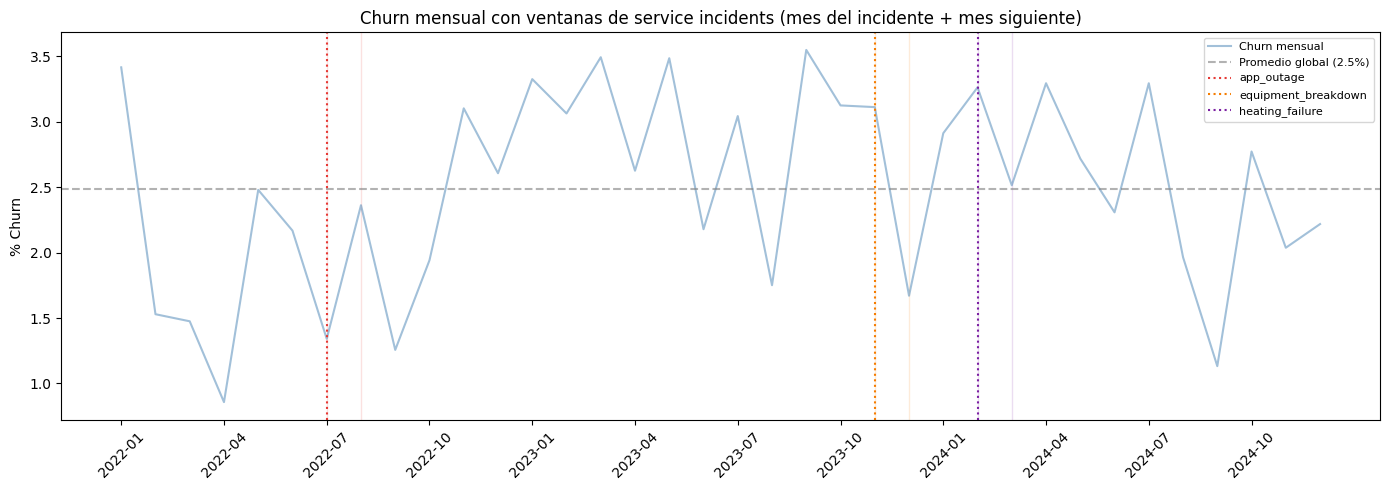


=== Churn en meses de incidentes vs promedio global ===
Promedio global: 2.48%

Incidente: app_outage
  2022-07 (mes incidente): 1.34%  (delta vs promedio: -1.14pp)
  2022-08 (mes siguiente): 2.36%  (delta vs promedio: -0.12pp)

Incidente: equipment_breakdown
  2023-11 (mes incidente): 3.11%  (delta vs promedio: +0.63pp)
  2023-12 (mes siguiente): 1.67%  (delta vs promedio: -0.81pp)

Incidente: heating_failure
  2024-02 (mes incidente): 3.26%  (delta vs promedio: +0.78pp)
  2024-03 (mes siguiente): 2.51%  (delta vs promedio: +0.03pp)



In [15]:
# Mes del incidente y el mes siguiente (lag +1)
incident_months = df_context[df_context['service_incident'].notna()][['month', 'service_incident']].copy()

# Obtener índice temporal para calcular mes siguiente
df_context_sorted = df_context.sort_values('month').reset_index(drop=True)
months_list = df_context_sorted['month'].tolist()

incident_windows = []
for _, row in incident_months.iterrows():
    idx = months_list.index(row['month'])
    window = [row['month']]
    if idx + 1 < len(months_list):
        window.append(months_list[idx + 1])
    incident_windows.append({'incident': row['service_incident'], 'months': window})

# Churn rate por mes (ya calculado en P6)
churn_rate_map = churn_by_month.set_index('month')['churn_rate'].to_dict()
global_avg_churn = churn_by_month['churn_rate'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(churn_ctx['month'], churn_ctx['churn_rate'], color='steelblue', linewidth=1.5, alpha=0.5, label='Churn mensual')
ax.axhline(global_avg_churn, color='gray', linestyle='--', alpha=0.6, label=f'Promedio global ({global_avg_churn:.1f}%)')

colors_inc = {'app_outage': '#e53935', 'equipment_breakdown': '#f57c00', 'heating_failure': '#7b1fa2'}
for w in incident_windows:
    for m in w['months']:
        if m in churn_rate_map:
            ax.axvspan(m, m, alpha=0.15, color=colors_inc.get(w['incident'], 'gray'))
    # Marcar mes del incidente
    m0 = w['months'][0]
    ax.axvline(m0, color=colors_inc.get(w['incident'], 'gray'), linestyle=':', linewidth=1.5,
               label=w['incident'])

ax.set_title('Churn mensual con ventanas de service incidents (mes del incidente + mes siguiente)')
ax.set_ylabel('% Churn')
ax.legend(loc='upper right', fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.set_xticks([churn_ctx['month'].iloc[i] for i in range(0, len(churn_ctx), 3)])
plt.tight_layout()
plt.show()

# Tabla comparativa: mes del incidente, mes antes, mes después
print("\n=== Churn en meses de incidentes vs promedio global ===")
print(f"Promedio global: {global_avg_churn:.2f}%\n")
for w in incident_windows:
    print(f"Incidente: {w['incident']}")
    for m in w['months']:
        tag = "(mes incidente)" if m == w['months'][0] else "(mes siguiente)"
        rate = churn_rate_map.get(m, None)
        if rate is not None:
            delta = rate - global_avg_churn
            print(f"  {m} {tag}: {rate:.2f}%  (delta vs promedio: {delta:+.2f}pp)")
    print()


# Engagement y Uso

## P11. Visitas: activos vs miembros que luego churnan

/var/folders/4g/7fk9ft1s6kn6mdjw1fcfbw0c0000gn/T/ipykernel_333/484198585.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=visits_by_status, x='status', y='avg_visits',
/var/folders/4g/7fk9ft1s6kn6mdjw1fcfbw0c0000gn/T/ipykernel_333/484198585.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=compare_df, x='group', y='visits',


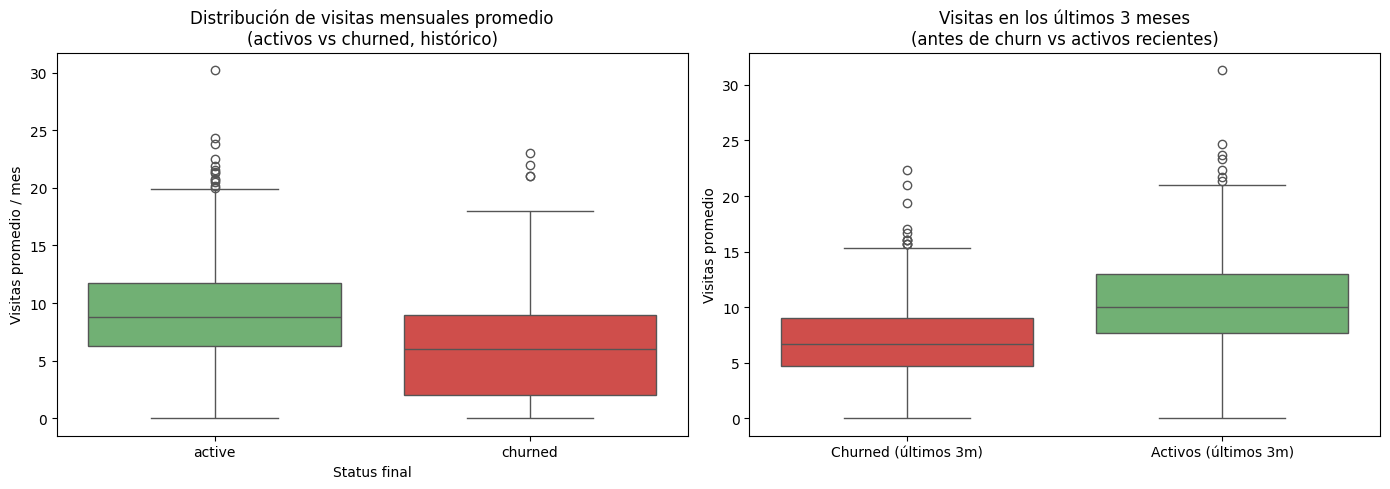

Visitas promedio — Activos: 9.2
Visitas promedio — Churned: 5.9

Últimos 3 meses — Activos: 10.6  |  Churned: 7.0


In [16]:
# Promedio de visitas por miembro según su status final
visits_by_status = (
    df_members.groupby(['member_id', 'status'])['visits_this_month']
    .mean()
    .reset_index()
    .rename(columns={'visits_this_month': 'avg_visits'})
)

# Visitas en los últimos 3 meses antes del churn vs activos
churned_ids = df_members[df_members['status'] == 'churned']['member_id'].unique()
active_ids = last_record[last_record['status'] == 'active']['member_id'].unique()

# Últimos 3 meses de cada miembro churned
last3_churned = (
    df_members[df_members['member_id'].isin(churned_ids)]
    .sort_values('month')
    .groupby('member_id')
    .tail(3)
    .groupby('member_id')['visits_this_month']
    .mean()
)

# Últimos 3 meses de activos (misma ventana)
last3_active = (
    df_members[df_members['member_id'].isin(active_ids)]
    .sort_values('month')
    .groupby('member_id')
    .tail(3)
    .groupby('member_id')['visits_this_month']
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de distribución de visitas promedio por status final
import seaborn as sns
sns.boxplot(data=visits_by_status, x='status', y='avg_visits',
            palette={'active': '#66bb6a', 'churned': '#e53935'}, ax=axes[0])
axes[0].set_title('Distribución de visitas mensuales promedio\n(activos vs churned, histórico)')
axes[0].set_xlabel('Status final')
axes[0].set_ylabel('Visitas promedio / mes')

# Comparación últimos 3 meses
compare_df = pd.DataFrame({
    'visits': list(last3_churned) + list(last3_active),
    'group': ['Churned (últimos 3m)'] * len(last3_churned) + ['Activos (últimos 3m)'] * len(last3_active)
})
sns.boxplot(data=compare_df, x='group', y='visits',
            palette={'Churned (últimos 3m)': '#e53935', 'Activos (últimos 3m)': '#66bb6a'}, ax=axes[1])
axes[1].set_title('Visitas en los últimos 3 meses\n(antes de churn vs activos recientes)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Visitas promedio')

plt.tight_layout()
plt.show()

print(f"Visitas promedio — Activos: {visits_by_status[visits_by_status['status']=='active']['avg_visits'].mean():.1f}")
print(f"Visitas promedio — Churned: {visits_by_status[visits_by_status['status']=='churned']['avg_visits'].mean():.1f}")
print(f"\nÚltimos 3 meses — Activos: {last3_active.mean():.1f}  |  Churned: {last3_churned.mean():.1f}")


## P12. Clases grupales y actividad general

/var/folders/4g/7fk9ft1s6kn6mdjw1fcfbw0c0000gn/T/ipykernel_333/3413357116.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=active_df, x='plan', y='group_classes_attended',
/var/folders/4g/7fk9ft1s6kn6mdjw1fcfbw0c0000gn/T/ipykernel_333/3413357116.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=classes_churn, x='status', y='avg_classes',


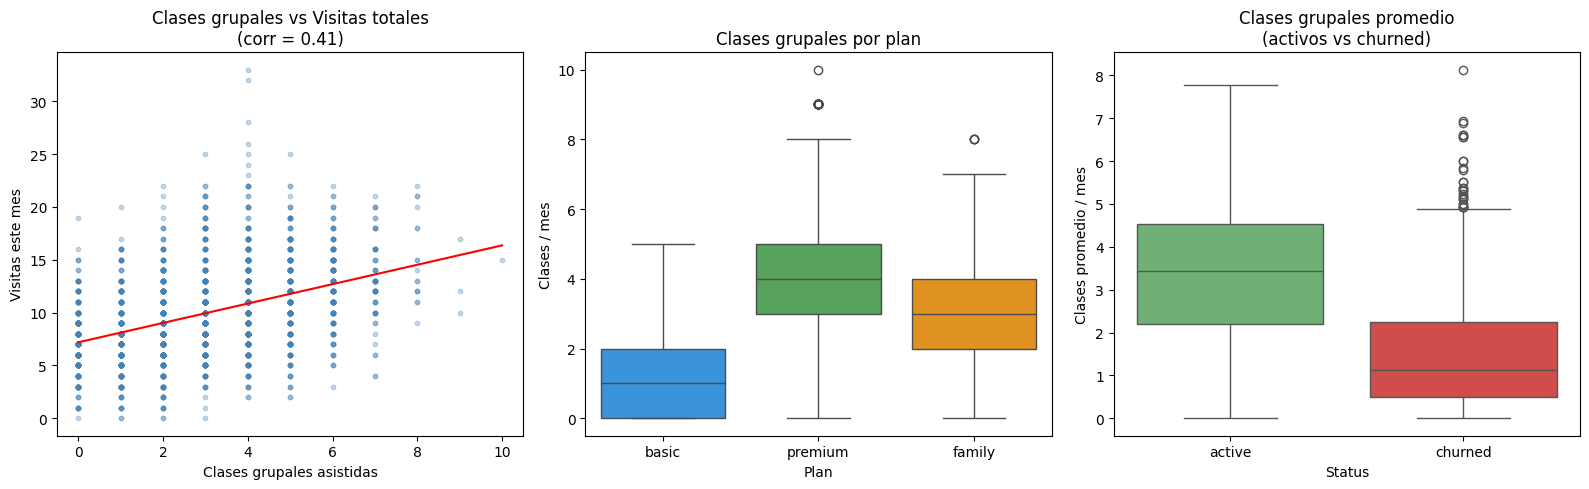

Correlación clases grupales–visitas: 0.412

Clases promedio — Activos: 3.39
Clases promedio — Churned: 1.65


In [19]:
active_df = df_members[df_members['status'] == 'active'].copy()

# Correlación clases grupales vs visitas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter: clases vs visitas
sample = active_df.sample(min(2000, len(active_df)), random_state=42)
axes[0].scatter(sample['group_classes_attended'], sample['visits_this_month'],
                alpha=0.3, color='steelblue', s=10)
# Línea de tendencia
z = np.polyfit(sample['group_classes_attended'], sample['visits_this_month'], 1)
p = np.poly1d(z)
x_line = sorted(sample['group_classes_attended'].unique())
axes[0].plot(x_line, p(x_line), color='red', linewidth=1.5)
corr = sample['group_classes_attended'].corr(sample['visits_this_month'])
axes[0].set_title(f'Clases grupales vs Visitas totales\n(corr = {corr:.2f})')
axes[0].set_xlabel('Clases grupales asistidas')
axes[0].set_ylabel('Visitas este mes')

# Distribución de clases por plan
sns.boxplot(data=active_df, x='plan', y='group_classes_attended',
            order=['basic','premium','family'],
            palette=['#2196F3','#4CAF50','#FF9800'], ax=axes[1])
axes[1].set_title('Clases grupales por plan')
axes[1].set_xlabel('Plan')
axes[1].set_ylabel('Clases / mes')

# Asistencia a clases vs churn
classes_churn = (
    df_members.groupby('member_id')
    .agg(avg_classes=('group_classes_attended', 'mean'), status=('status', 'last'))
    .reset_index()
)
sns.boxplot(data=classes_churn, x='status', y='avg_classes',
            palette={'active': '#66bb6a', 'churned': '#e53935'}, ax=axes[2])
axes[2].set_title('Clases grupales promedio\n(activos vs churned)')
axes[2].set_xlabel('Status')
axes[2].set_ylabel('Clases promedio / mes')

plt.tight_layout()
plt.show()

print(f"Correlación clases grupales–visitas: {corr:.3f}")
print(f"\nClases promedio — Activos: {classes_churn[classes_churn['status']=='active']['avg_classes'].mean():.2f}")
print(f"Clases promedio — Churned: {classes_churn[classes_churn['status']=='churned']['avg_classes'].mean():.2f}")


## P13. Estacionalidad en visitas

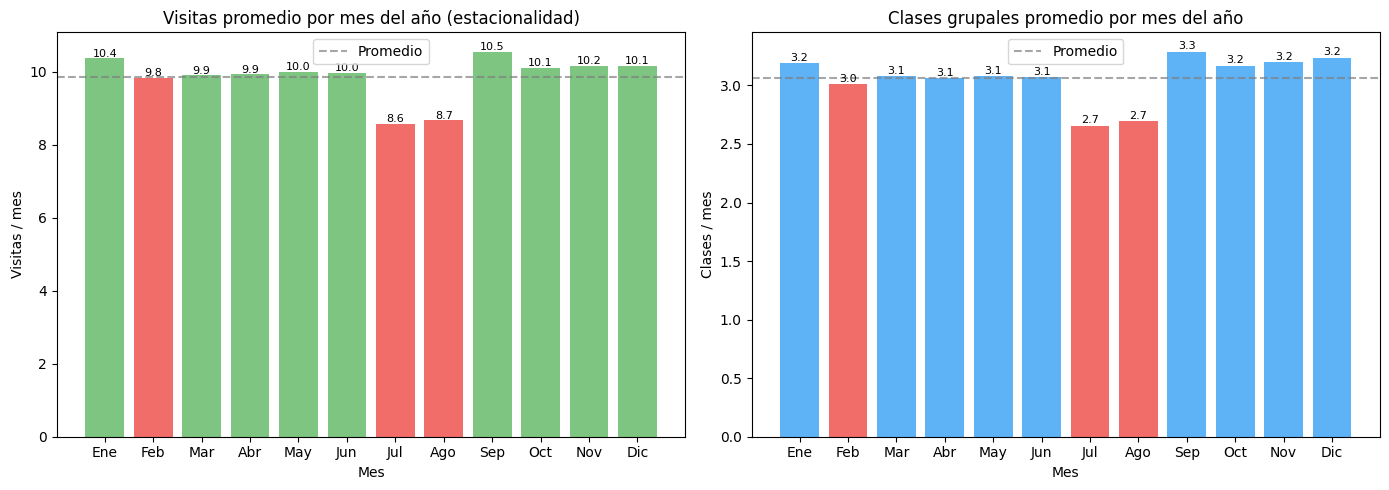

Mes con más visitas: Sep (10.5)
Mes con menos visitas: Jul (8.6)
Variación estacional (max/min): 1.23x


In [20]:
import numpy as np

# Extraer el mes del año (1-12) para análisis estacional
df_members['month_num'] = df_members['month'].str[-2:].astype(int)
month_names = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
               7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

seasonality = (
    df_members[df_members['status'] == 'active']
    .groupby('month_num')
    .agg(avg_visits=('visits_this_month', 'mean'),
         avg_classes=('group_classes_attended', 'mean'))
    .reset_index()
)
seasonality['month_label'] = seasonality['month_num'].map(month_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visitas por mes del año
bars = axes[0].bar(seasonality['month_label'], seasonality['avg_visits'],
                   color=['#ef5350' if v < seasonality['avg_visits'].mean() else '#66bb6a'
                          for v in seasonality['avg_visits']], alpha=0.85)
axes[0].axhline(seasonality['avg_visits'].mean(), color='gray', linestyle='--', alpha=0.7, label='Promedio')
axes[0].set_title('Visitas promedio por mes del año (estacionalidad)')
axes[0].set_ylabel('Visitas / mes')
axes[0].set_xlabel('Mes')
axes[0].legend()
for bar, v in zip(bars, seasonality['avg_visits']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.05, f'{v:.1f}', ha='center', fontsize=8)

# Clases grupales por mes
bars2 = axes[1].bar(seasonality['month_label'], seasonality['avg_classes'],
                    color=['#ef5350' if v < seasonality['avg_classes'].mean() else '#42a5f5'
                           for v in seasonality['avg_classes']], alpha=0.85)
axes[1].axhline(seasonality['avg_classes'].mean(), color='gray', linestyle='--', alpha=0.7, label='Promedio')
axes[1].set_title('Clases grupales promedio por mes del año')
axes[1].set_ylabel('Clases / mes')
axes[1].set_xlabel('Mes')
axes[1].legend()
for bar, v in zip(bars2, seasonality['avg_classes']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.1f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("Mes con más visitas:", seasonality.loc[seasonality['avg_visits'].idxmax(), 'month_label'],
      f"({seasonality['avg_visits'].max():.1f})")
print("Mes con menos visitas:", seasonality.loc[seasonality['avg_visits'].idxmin(), 'month_label'],
      f"({seasonality['avg_visits'].min():.1f})")
print(f"Variación estacional (max/min): {seasonality['avg_visits'].max()/seasonality['avg_visits'].min():.2f}x")


## P14. Miembros con cero visitas en el mes

/var/folders/4g/7fk9ft1s6kn6mdjw1fcfbw0c0000gn/T/ipykernel_333/1654824678.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['visits_this_month'] == 0).sum() / len(x) * 100)
/var/folders/4g/7fk9ft1s6kn6mdjw1fcfbw0c0000gn/T/ipykernel_333/1654824678.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['visits_this_month'] == 0).sum() / len(x) * 100)
/var/folders/4g/7fk9ft1s6kn6m

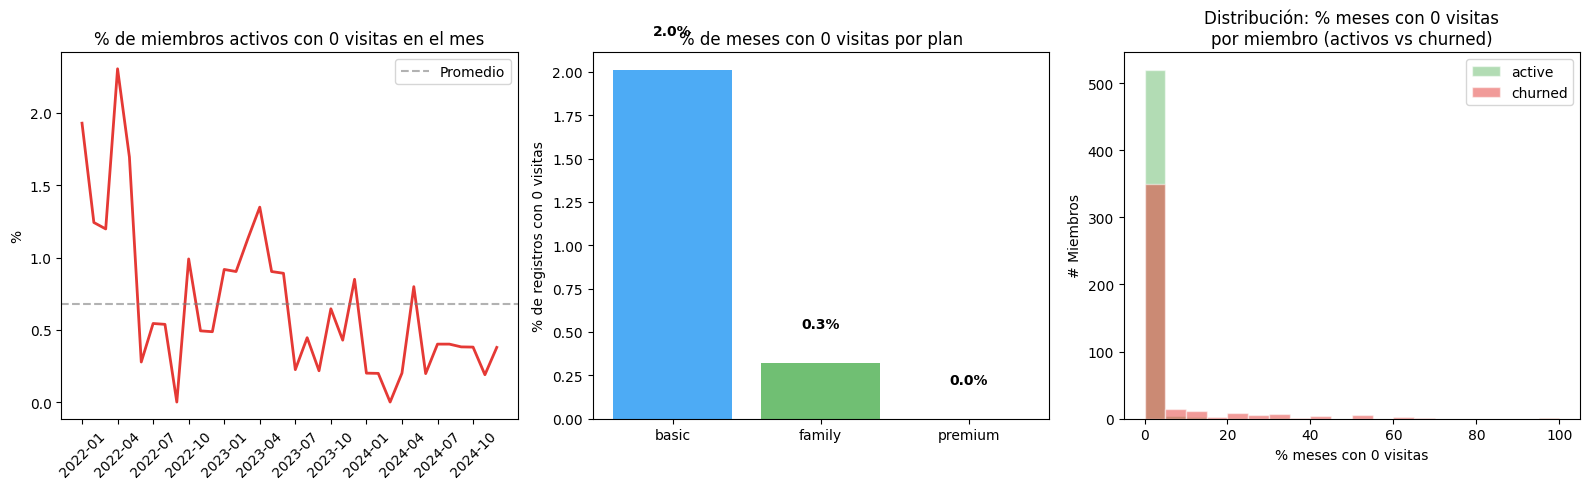


% promedio de registros activos con 0 visitas: 0.7%
Plan con más 0 visitas: basic (2.0%)


In [21]:
zero_visits = df_members[df_members['visits_this_month'] == 0].copy()

# % de registros con 0 visitas sobre total activos por mes
zero_by_month = (
    df_members[df_members['status'] == 'active']
    .groupby('month')
    .apply(lambda x: (x['visits_this_month'] == 0).sum() / len(x) * 100)
    .reset_index(name='pct_zero_visits')
)

# % de cero visitas por plan
zero_by_plan = (
    df_members[df_members['status'] == 'active']
    .groupby('plan')
    .apply(lambda x: (x['visits_this_month'] == 0).sum() / len(x) * 100)
    .reset_index(name='pct_zero')
)

# Churn rate de quienes tienen muchos meses con 0 visitas
members_zero = (
    df_members.groupby('member_id')
    .apply(lambda x: {
        'pct_zero_months': (x['visits_this_month'] == 0).sum() / len(x) * 100,
        'status': x['status'].iloc[-1]
    })
    .apply(pd.Series)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# % de 0 visitas por mes
axes[0].plot(zero_by_month['month'], zero_by_month['pct_zero_visits'], color='#e53935', linewidth=2)
axes[0].axhline(zero_by_month['pct_zero_visits'].mean(), color='gray', linestyle='--', alpha=0.6, label='Promedio')
axes[0].set_title('% de miembros activos con 0 visitas en el mes')
axes[0].set_ylabel('%')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xticks([zero_by_month['month'].iloc[i] for i in range(0, len(zero_by_month), 3)])

# % por plan
axes[1].bar(zero_by_plan['plan'], zero_by_plan['pct_zero'],
            color=['#2196F3','#4CAF50','#FF9800','#9C27B0'][:len(zero_by_plan)], alpha=0.8)
axes[1].set_title('% de meses con 0 visitas por plan')
axes[1].set_ylabel('% de registros con 0 visitas')
for i, v in enumerate(zero_by_plan['pct_zero']):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Histograma del % de meses con 0 visitas por miembro, separado por status
for status, color in [('active', '#66bb6a'), ('churned', '#e53935')]:
    subset = members_zero[members_zero['status'] == status]['pct_zero_months']
    axes[2].hist(subset, bins=20, alpha=0.5, color=color, label=status, edgecolor='white')
axes[2].set_title('Distribución: % meses con 0 visitas\npor miembro (activos vs churned)')
axes[2].set_xlabel('% meses con 0 visitas')
axes[2].set_ylabel('# Miembros')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\n% promedio de registros activos con 0 visitas: {zero_by_month['pct_zero_visits'].mean():.1f}%")
print(f"Plan con más 0 visitas: {zero_by_plan.loc[zero_by_plan['pct_zero'].idxmax(), 'plan']} ({zero_by_plan['pct_zero'].max():.1f}%)")


# Canales de Adquisición

## P15. Volumen de adquisición y retención por canal

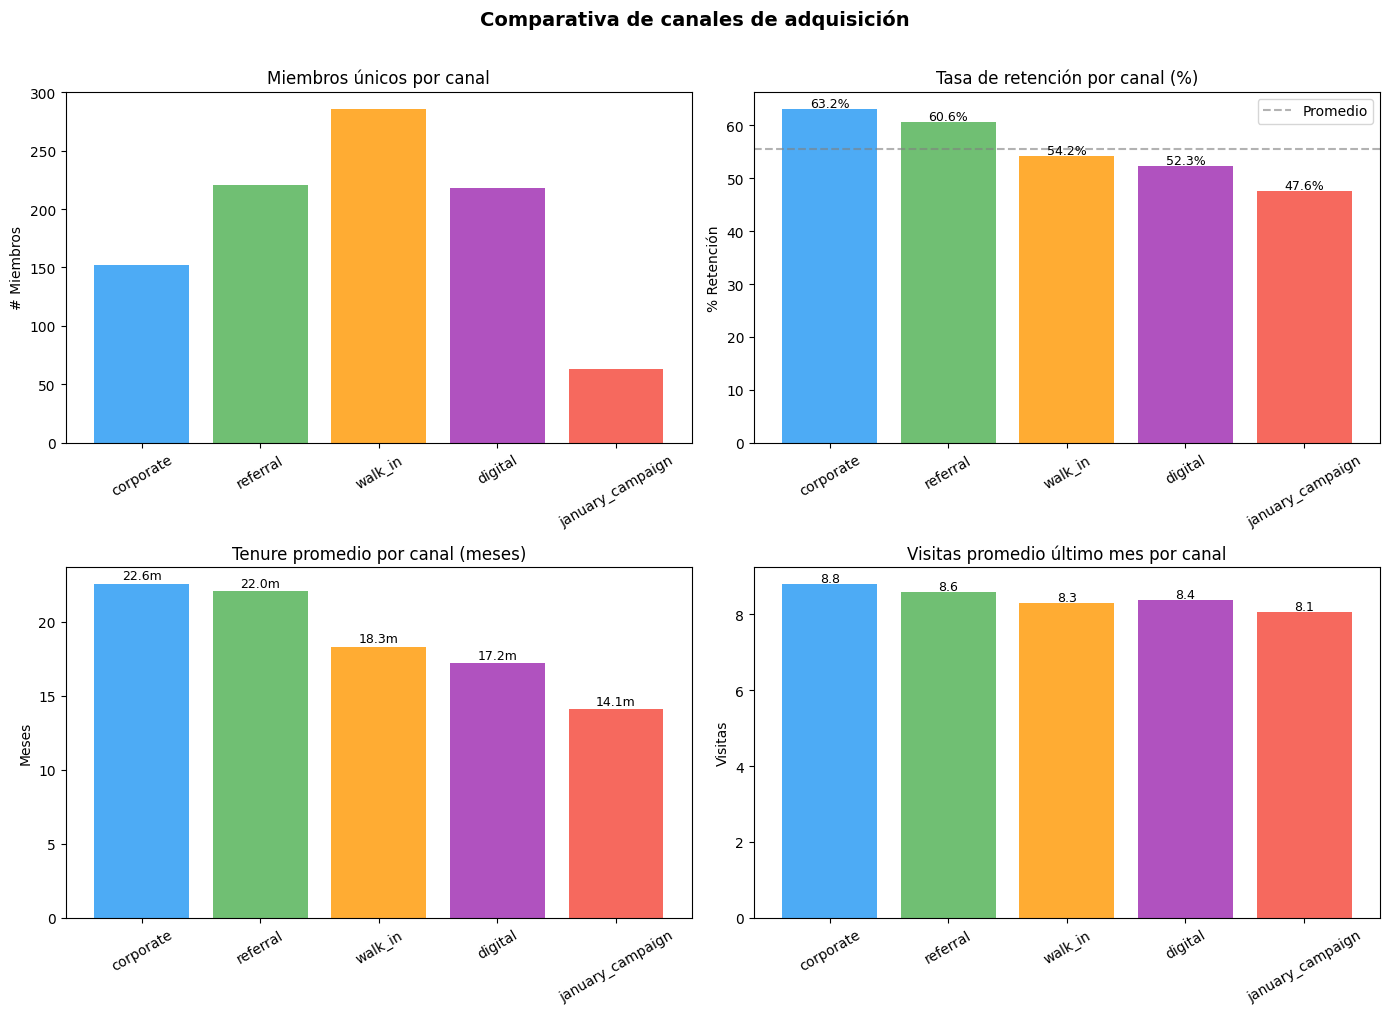

acquisition_channel  n_members  churn_rate  retention_rate  avg_tenure  avg_visits
          corporate        152   36.842105       63.157895   22.565789    8.815789
           referral        221   39.366516       60.633484   22.040724    8.601810
            walk_in        286   45.804196       54.195804   18.297203    8.314685
            digital        218   47.706422       52.293578   17.201835    8.371560
   january_campaign         63   52.380952       47.619048   14.079365    8.063492


In [22]:
channel_summary = (
    last_record.groupby('acquisition_channel')
    .agg(
        n_members=('member_id', 'count'),
        n_churned=('status', lambda x: (x == 'churned').sum()),
        avg_tenure=('tenure_months', 'mean'),
        avg_visits=('visits_this_month', 'mean')
    )
    .reset_index()
)
channel_summary['churn_rate'] = channel_summary['n_churned'] / channel_summary['n_members'] * 100
channel_summary['retention_rate'] = 100 - channel_summary['churn_rate']
channel_summary = channel_summary.sort_values('churn_rate')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

channels = channel_summary['acquisition_channel']
colors_ch = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']

# Volumen de miembros
axes[0,0].bar(channels, channel_summary['n_members'], color=colors_ch[:len(channels)], alpha=0.8)
axes[0,0].set_title('Miembros únicos por canal')
axes[0,0].set_ylabel('# Miembros')
axes[0,0].tick_params(axis='x', rotation=30)

# Tasa de retención
bars = axes[0,1].bar(channels, channel_summary['retention_rate'], color=colors_ch[:len(channels)], alpha=0.8)
axes[0,1].axhline(channel_summary['retention_rate'].mean(), color='gray', linestyle='--', alpha=0.6, label='Promedio')
axes[0,1].set_title('Tasa de retención por canal (%)')
axes[0,1].set_ylabel('% Retención')
axes[0,1].legend()
axes[0,1].tick_params(axis='x', rotation=30)
for bar, v in zip(bars, channel_summary['retention_rate']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# Tenure promedio
axes[1,0].bar(channels, channel_summary['avg_tenure'], color=colors_ch[:len(channels)], alpha=0.8)
axes[1,0].set_title('Tenure promedio por canal (meses)')
axes[1,0].set_ylabel('Meses')
axes[1,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(channel_summary['avg_tenure']):
    axes[1,0].text(i, v + 0.3, f'{v:.1f}m', ha='center', fontsize=9)

# Visitas promedio del último mes
axes[1,1].bar(channels, channel_summary['avg_visits'], color=colors_ch[:len(channels)], alpha=0.8)
axes[1,1].set_title('Visitas promedio último mes por canal')
axes[1,1].set_ylabel('Visitas')
axes[1,1].tick_params(axis='x', rotation=30)
for i, v in enumerate(channel_summary['avg_visits']):
    axes[1,1].text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=9)

plt.suptitle('Comparativa de canales de adquisición', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(channel_summary[['acquisition_channel','n_members','churn_rate','retention_rate','avg_tenure','avg_visits']].to_string(index=False))


## P16. Canal corporate vs walk-in: comportamiento diferencial

/var/folders/4g/7fk9ft1s6kn6mdjw1fcfbw0c0000gn/T/ipykernel_333/2996115197.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_focus[df_focus['status']=='active'], x='acquisition_channel', y=col,
/var/folders/4g/7fk9ft1s6kn6mdjw1fcfbw0c0000gn/T/ipykernel_333/2996115197.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_focus[df_focus['status']=='active'], x='acquisition_channel', y=col,
/var/folders/4g/7fk9ft1s6kn6mdjw1fcfbw0c0000gn/T/ipykernel_333/2996115197.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_focu

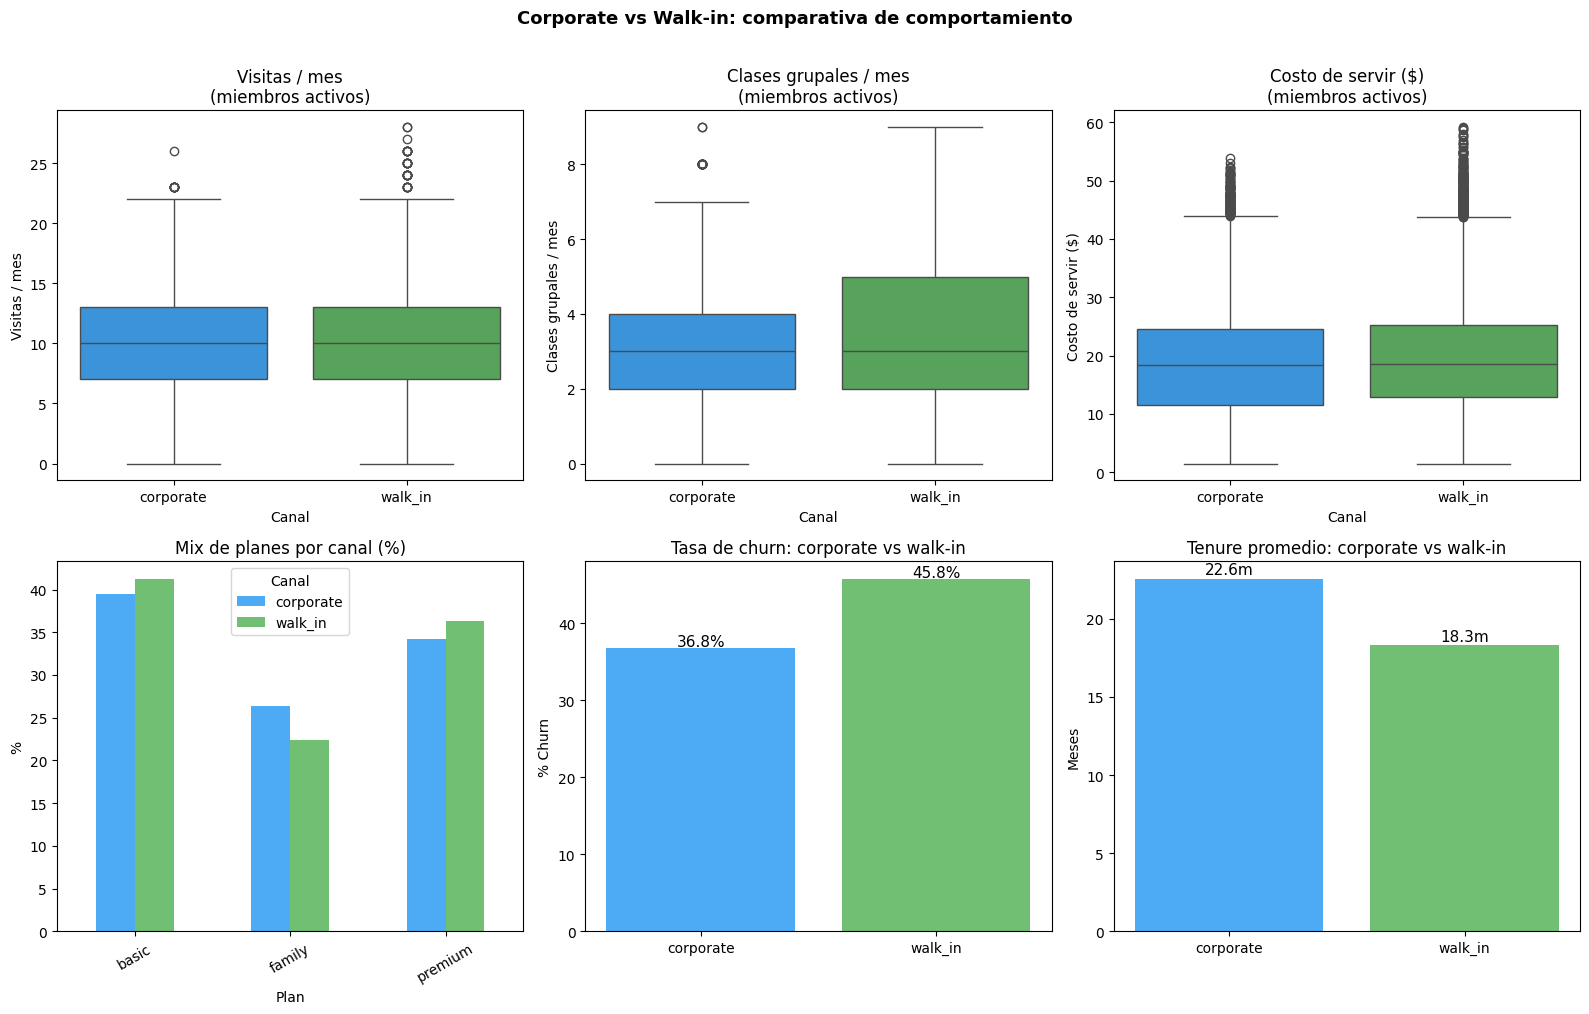

In [23]:
focus_channels = ['corporate', 'walk_in']
df_focus = df_members[df_members['acquisition_channel'].isin(focus_channels)].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics = [
    ('visits_this_month', 'Visitas / mes'),
    ('group_classes_attended', 'Clases grupales / mes'),
    ('cost_to_serve', 'Costo de servir ($)')
]

for i, (col, label) in enumerate(metrics):
    sns.boxplot(data=df_focus[df_focus['status']=='active'], x='acquisition_channel', y=col,
                order=focus_channels, palette=['#2196F3','#4CAF50'], ax=axes[0, i])
    axes[0, i].set_title(f'{label}\n(miembros activos)')
    axes[0, i].set_xlabel('Canal')
    axes[0, i].set_ylabel(label)

# Mix de planes por canal
plan_channel = (
    last_record[last_record['acquisition_channel'].isin(focus_channels)]
    .groupby(['acquisition_channel', 'plan'])
    .size()
    .reset_index(name='count')
)
plan_pivot = plan_channel.pivot(index='plan', columns='acquisition_channel', values='count').fillna(0)
plan_pivot_pct = plan_pivot.div(plan_pivot.sum()) * 100
plan_pivot_pct.plot(kind='bar', ax=axes[1, 0], color=['#2196F3','#4CAF50'], alpha=0.8)
axes[1, 0].set_title('Mix de planes por canal (%)')
axes[1, 0].set_ylabel('%')
axes[1, 0].set_xlabel('Plan')
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].legend(title='Canal')

# Churn por canal
cr_focus = (
    last_record[last_record['acquisition_channel'].isin(focus_channels)]
    .groupby('acquisition_channel')['status']
    .apply(lambda x: (x == 'churned').sum() / len(x) * 100)
    .reset_index(name='churn_rate')
)
bars = axes[1, 1].bar(cr_focus['acquisition_channel'], cr_focus['churn_rate'],
                      color=['#2196F3','#4CAF50'], alpha=0.8)
axes[1, 1].set_title('Tasa de churn: corporate vs walk-in')
axes[1, 1].set_ylabel('% Churn')
for bar, v in zip(bars, cr_focus['churn_rate']):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, v + 0.2, f'{v:.1f}%', ha='center', fontsize=11)

# Tenure promedio
tenure_focus = (
    last_record[last_record['acquisition_channel'].isin(focus_channels)]
    .groupby('acquisition_channel')['tenure_months']
    .mean()
    .reset_index()
)
axes[1, 2].bar(tenure_focus['acquisition_channel'], tenure_focus['tenure_months'],
               color=['#2196F3','#4CAF50'], alpha=0.8)
axes[1, 2].set_title('Tenure promedio: corporate vs walk-in')
axes[1, 2].set_ylabel('Meses')
for i, v in enumerate(tenure_focus['tenure_months']):
    axes[1, 2].text(i, v + 0.3, f'{v:.1f}m', ha='center', fontsize=11)

plt.suptitle('Corporate vs Walk-in: comparativa de comportamiento', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# Campañas y Contexto Externo

## P17. Efecto de campañas en adquisición de nuevos miembros

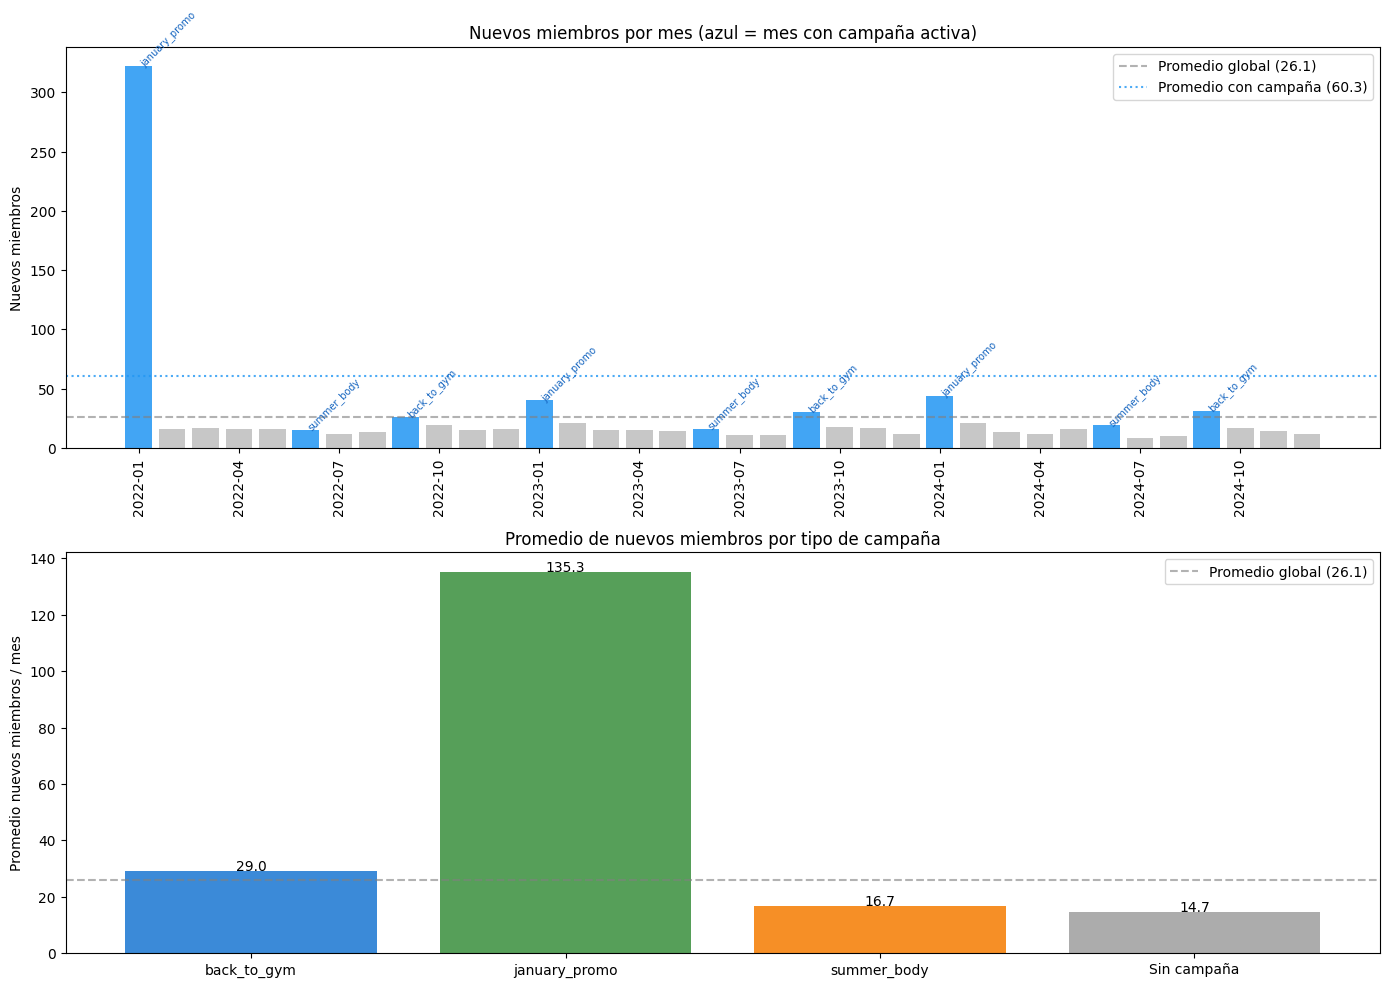


Promedio global: 26.1 nuevos miembros/mes
Promedio meses CON campaña: 60.3  (+131.1% vs promedio)
Promedio meses SIN campaña: 14.7

     campaign    avg_new  n_months
  back_to_gym  29.000000         3
january_promo 135.333333         3
  summer_body  16.666667         3
  Sin campaña  14.703704        27


In [24]:
# Nuevos miembros por mes = primera aparición de cada member_id
first_month = df_members.groupby('member_id')['month'].min().reset_index(name='signup_month')
new_members_per_month = first_month.groupby('signup_month').size().reset_index(name='new_members')

# Merge con campañas
new_vs_campaign = new_members_per_month.merge(
    df_context[['month', 'campaign_active', 'service_incident']],
    left_on='signup_month', right_on='month', how='left'
)

avg_new = new_vs_campaign['new_members'].mean()
campaign_avg = new_vs_campaign[new_vs_campaign['campaign_active'].notna()]['new_members'].mean()
no_campaign_avg = new_vs_campaign[new_vs_campaign['campaign_active'].isna()]['new_members'].mean()

# Comparar por tipo de campaña
campaign_effect = (
    new_vs_campaign.groupby('campaign_active')['new_members']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)
campaign_effect.columns = ['campaign', 'avg_new', 'median_new', 'n_months']
no_camp_row = pd.DataFrame([{'campaign': 'Sin campaña',
                              'avg_new': no_campaign_avg,
                              'median_new': new_vs_campaign[new_vs_campaign['campaign_active'].isna()]['new_members'].median(),
                              'n_months': new_vs_campaign['campaign_active'].isna().sum()}])
campaign_effect = pd.concat([campaign_effect.dropna(subset=['campaign']), no_camp_row], ignore_index=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Panel 1: nuevos miembros por mes con campaña marcada
bar_colors = []
for _, row in new_vs_campaign.iterrows():
    if pd.notna(row['campaign_active']):
        bar_colors.append('#2196F3')
    else:
        bar_colors.append('#bdbdbd')

axes[0].bar(new_vs_campaign['signup_month'], new_vs_campaign['new_members'],
            color=bar_colors, alpha=0.85)
axes[0].axhline(avg_new, color='gray', linestyle='--', alpha=0.6, label=f'Promedio global ({avg_new:.1f})')
axes[0].axhline(campaign_avg, color='#2196F3', linestyle=':', alpha=0.8, label=f'Promedio con campaña ({campaign_avg:.1f})')

# Anotar nombre de campaña
for _, row in new_vs_campaign[new_vs_campaign['campaign_active'].notna()].iterrows():
    axes[0].text(row['signup_month'], row['new_members'] + 0.3,
                 row['campaign_active'], rotation=45, fontsize=7, color='#1565c0')

axes[0].set_title('Nuevos miembros por mes (azul = mes con campaña activa)')
axes[0].set_ylabel('Nuevos miembros')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_xticks([new_vs_campaign['signup_month'].iloc[i] for i in range(0, len(new_vs_campaign), 3)])

# Panel 2: promedio de adquisición por tipo de campaña
bars = axes[1].bar(campaign_effect['campaign'], campaign_effect['avg_new'],
                   color=['#1976D2','#388E3C','#F57C00','#9E9E9E'][:len(campaign_effect)], alpha=0.85)
axes[1].axhline(avg_new, color='gray', linestyle='--', alpha=0.6, label=f'Promedio global ({avg_new:.1f})')
axes[1].set_title('Promedio de nuevos miembros por tipo de campaña')
axes[1].set_ylabel('Promedio nuevos miembros / mes')
axes[1].legend()
for bar, v in zip(bars, campaign_effect['avg_new']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.2, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nPromedio global: {avg_new:.1f} nuevos miembros/mes")
print(f"Promedio meses CON campaña: {campaign_avg:.1f}  ({(campaign_avg/avg_new-1)*100:+.1f}% vs promedio)")
print(f"Promedio meses SIN campaña: {no_campaign_avg:.1f}")
print(f"\n{campaign_effect[['campaign','avg_new','n_months']].to_string(index=False)}")


## P18. Campañas y ocupación del gimnasio

/var/folders/4g/7fk9ft1s6kn6mdjw1fcfbw0c0000gn/T/ipykernel_333/466375686.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=occ, x='categoria', y='avg_occupancy_rate',


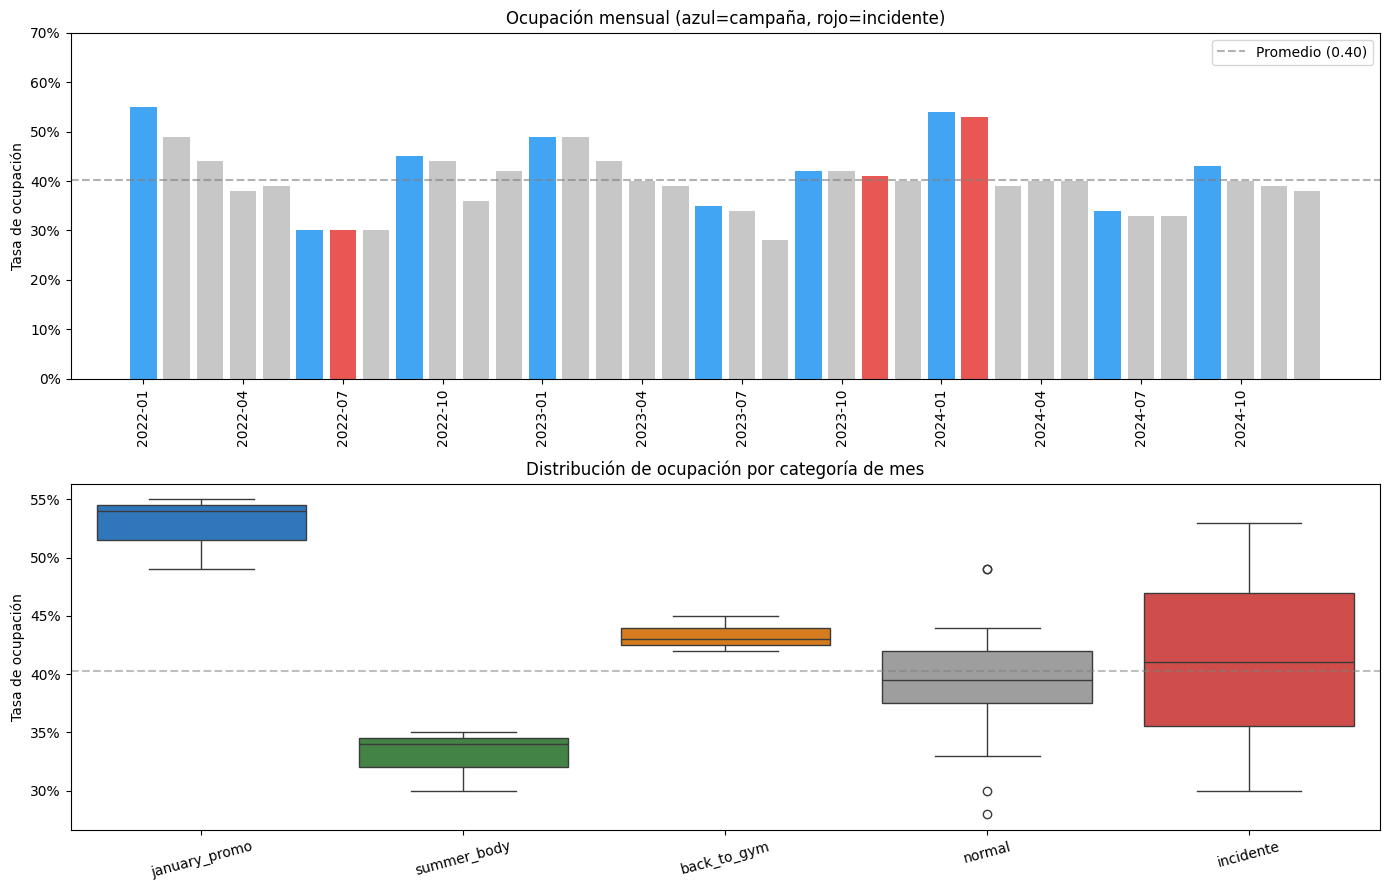


=== Ocupación promedio por categoría ===
                mean   min   max
categoria                       
back_to_gym    0.433  0.42  0.45
incidente      0.413  0.30  0.53
january_promo  0.527  0.49  0.55
normal         0.392  0.28  0.49
summer_body    0.330  0.30  0.35


In [25]:
occ = df_context[['month', 'avg_occupancy_rate', 'campaign_active', 'service_incident']].copy()
occ['has_campaign'] = occ['campaign_active'].notna()
occ['has_incident'] = occ['service_incident'].notna()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: ocupación en el tiempo con marcadores
line_colors = []
for _, row in occ.iterrows():
    if row['has_incident']:
        line_colors.append('#e53935')
    elif row['has_campaign']:
        line_colors.append('#2196F3')
    else:
        line_colors.append('#bdbdbd')

axes[0].bar(occ['month'], occ['avg_occupancy_rate'], color=line_colors, alpha=0.85)
axes[0].axhline(occ['avg_occupancy_rate'].mean(), color='gray', linestyle='--', alpha=0.6,
                label=f'Promedio ({occ["avg_occupancy_rate"].mean():.2f})')
axes[0].set_title('Ocupación mensual (azul=campaña, rojo=incidente)')
axes[0].set_ylabel('Tasa de ocupación')
axes[0].set_ylim(0, 0.7)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_xticks([occ['month'].iloc[i] for i in range(0, len(occ), 3)])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Panel 2: boxplot ocupación — campaña vs sin campaña vs incidente
occ['categoria'] = occ.apply(
    lambda r: r['campaign_active'] if r['has_campaign'] else ('incidente' if r['has_incident'] else 'normal'), axis=1
)
order_cat = ['january_promo', 'summer_body', 'back_to_gym', 'normal', 'incidente']
order_cat = [c for c in order_cat if c in occ['categoria'].values]
palette_cat = {
    'january_promo': '#1976D2', 'summer_body': '#388E3C', 'back_to_gym': '#F57C00',
    'normal': '#9E9E9E', 'incidente': '#e53935'
}

sns.boxplot(data=occ, x='categoria', y='avg_occupancy_rate',
            order=order_cat, palette=palette_cat, ax=axes[1])
axes[1].axhline(occ['avg_occupancy_rate'].mean(), color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Distribución de ocupación por categoría de mes')
axes[1].set_ylabel('Tasa de ocupación')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

print("\n=== Ocupación promedio por categoría ===")
print(occ.groupby('categoria')['avg_occupancy_rate'].agg(['mean','min','max']).round(3))


## P19. Visitas y churn en meses con service incidents

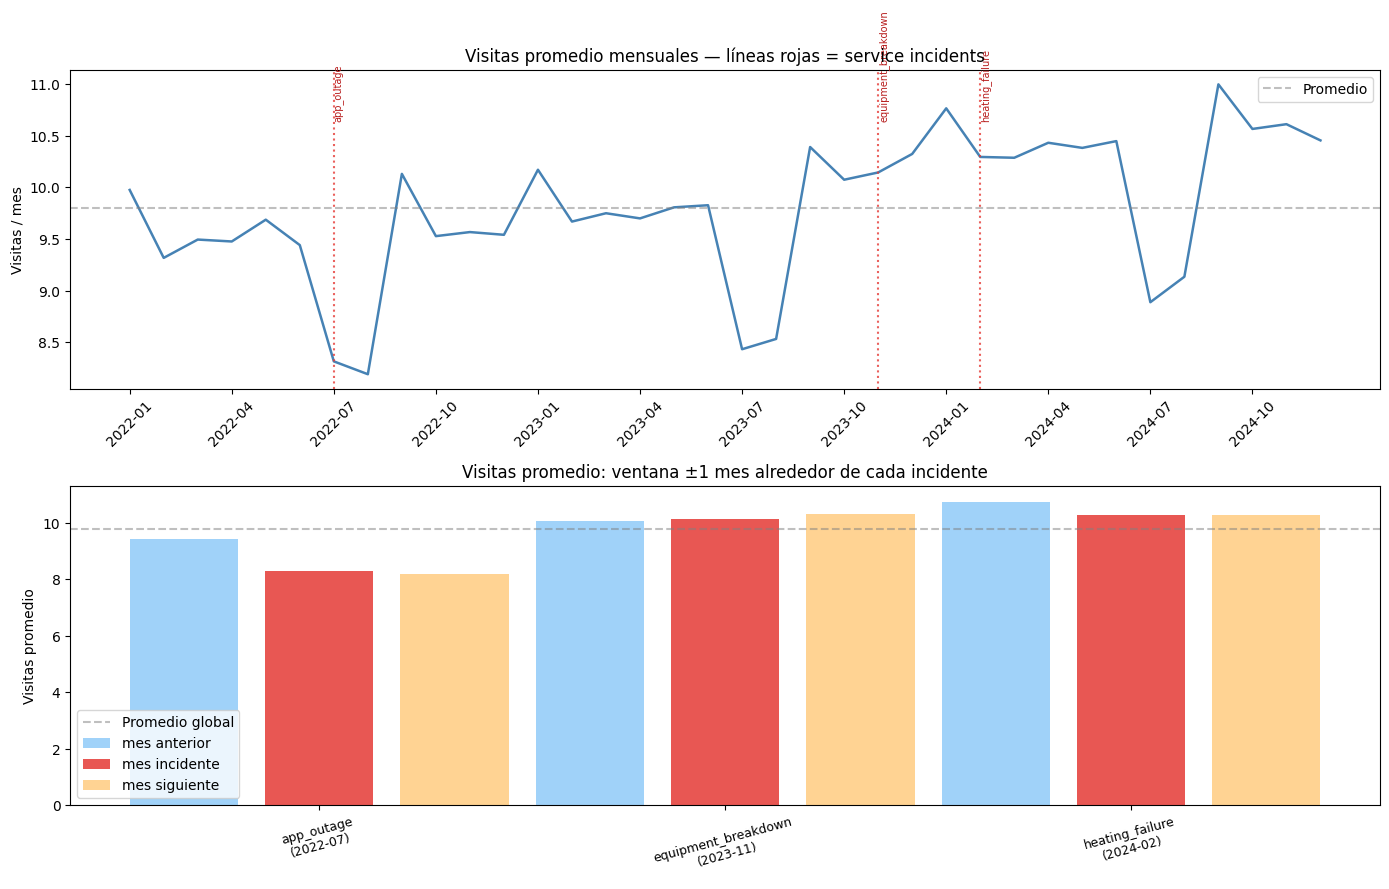


=== Detalle visitas y churn en ventanas de incidentes ===
          incidente       periodo   month  avg_visits  churn_rate
         app_outage  mes anterior 2022-06    9.440443    2.168022
         app_outage mes incidente 2022-07    8.315217    1.340483
         app_outage mes siguiente 2022-08    8.190860    2.362205
equipment_breakdown  mes anterior 2023-10   10.073118    3.125000
equipment_breakdown mes incidente 2023-11   10.143469    3.112033
equipment_breakdown mes siguiente 2023-12   10.322718    1.670146
    heating_failure  mes anterior 2024-01   10.764000    2.912621
    heating_failure mes incidente 2024-02   10.293651    3.262956
    heating_failure mes siguiente 2024-03   10.285714    2.514507


In [26]:
# Agregar visitas promedio por mes y añadir contexto
visits_monthly = (
    df_members[df_members['status'] == 'active']
    .groupby('month')['visits_this_month']
    .mean()
    .reset_index(name='avg_visits')
)
combined = visits_monthly.merge(churn_by_month[['month','churn_rate']], on='month')
combined = combined.merge(df_context[['month','service_incident','campaign_active']], on='month')
combined['has_incident'] = combined['service_incident'].notna()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: visitas con incidentes marcados
axes[0].plot(combined['month'], combined['avg_visits'], color='steelblue', linewidth=1.8)
for _, row in combined[combined['has_incident']].iterrows():
    axes[0].axvline(row['month'], color='#e53935', linestyle=':', linewidth=1.5, alpha=0.8)
    axes[0].text(row['month'], combined['avg_visits'].max() * 0.97,
                 row['service_incident'], rotation=90, fontsize=7, color='#b71c1c')
axes[0].axhline(combined['avg_visits'].mean(), color='gray', linestyle='--', alpha=0.5, label='Promedio')
axes[0].set_title('Visitas promedio mensuales — líneas rojas = service incidents')
axes[0].set_ylabel('Visitas / mes')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xticks([combined['month'].iloc[i] for i in range(0, len(combined), 3)])

# Panel 2: comparativa visitas e incidents (tabla visual)
incident_months_list = combined[combined['has_incident']]['month'].tolist()
window_data = []
for m in incident_months_list:
    idx = combined[combined['month'] == m].index[0]
    for offset, label in [(-1, 'mes anterior'), (0, 'mes incidente'), (1, 'mes siguiente')]:
        target_idx = idx + offset
        if 0 <= target_idx < len(combined):
            row = combined.iloc[target_idx]
            window_data.append({
                'incidente': combined.iloc[idx]['service_incident'],
                'periodo': label,
                'month': row['month'],
                'avg_visits': row['avg_visits'],
                'churn_rate': row['churn_rate']
            })

window_df = pd.DataFrame(window_data)
x = range(len(window_df))
width = 0.35
color_map = {'mes anterior': '#90caf9', 'mes incidente': '#e53935', 'mes siguiente': '#ffcc80'}
for periodo in ['mes anterior', 'mes incidente', 'mes siguiente']:
    subset = window_df[window_df['periodo'] == periodo]
    offset = {'mes anterior': -1, 'mes incidente': 0, 'mes siguiente': 1}[periodo]
    positions = [i * 3 + offset for i in range(len(subset))]
    axes[1].bar(positions, subset['avg_visits'], color=color_map[periodo], alpha=0.85, label=periodo, width=0.8)

axes[1].set_xticks([i * 3 for i in range(len(incident_months_list))])
axes[1].set_xticklabels([combined[combined['month']==m]['service_incident'].values[0]
                          + f'\n({m})' for m in incident_months_list], rotation=15, fontsize=9)
axes[1].axhline(combined['avg_visits'].mean(), color='gray', linestyle='--', alpha=0.5, label='Promedio global')
axes[1].set_title('Visitas promedio: ventana ±1 mes alrededor de cada incidente')
axes[1].set_ylabel('Visitas promedio')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n=== Detalle visitas y churn en ventanas de incidentes ===")
print(window_df[['incidente','periodo','month','avg_visits','churn_rate']].to_string(index=False))


# Análisis por Centro

## P20. Margen, ocupación y retención por centro

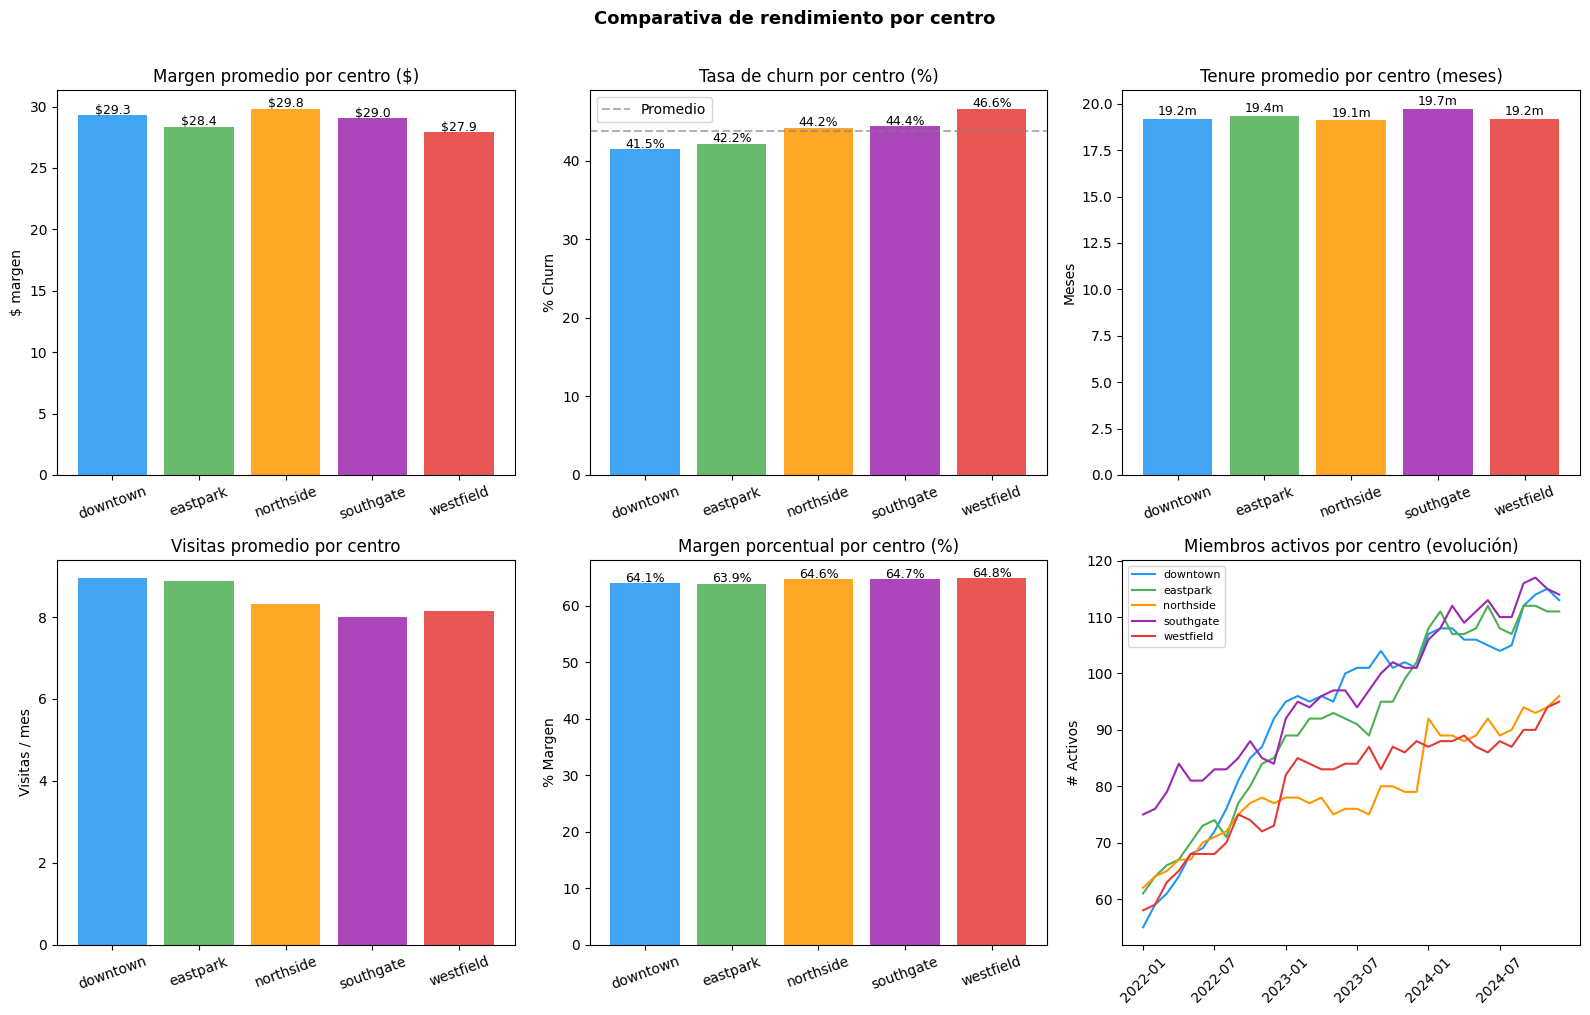

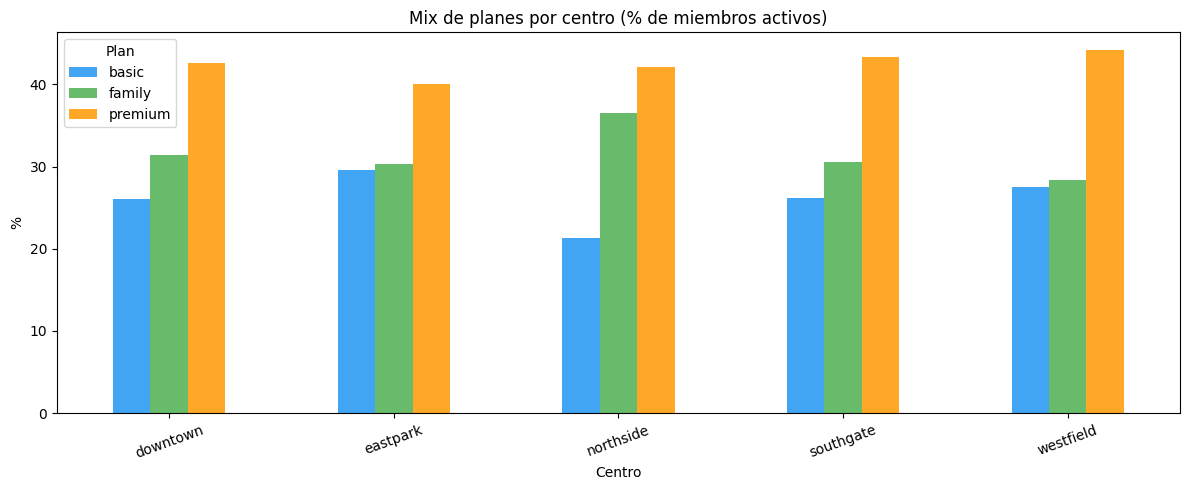


=== Resumen por centro ===
   center  n_members  churn_rate  avg_margin  margin_pct  avg_tenure  avg_visits
 downtown        193   41.450777   29.280570   64.079987   19.196891    8.943005
 eastpark        192   42.187500   28.377813   63.916241   19.359375    8.890625
northside        172   44.186047   29.833895   64.638979   19.110465    8.308140
southgate        205   44.390244   29.046585   64.695944   19.736585    7.995122
westfield        178   46.629213   27.893708   64.825047   19.191011    8.151685


In [27]:
center_summary = (
    last_record.groupby('center')
    .agg(
        n_members=('member_id', 'count'),
        n_churned=('status', lambda x: (x == 'churned').sum()),
        avg_tenure=('tenure_months', 'mean'),
        avg_visits=('visits_this_month', 'mean'),
        avg_price=('price_paid', 'mean'),
        avg_cost=('cost_to_serve', 'mean'),
        avg_margin=('margin', 'mean')
    )
    .reset_index()
)
center_summary['churn_rate'] = center_summary['n_churned'] / center_summary['n_members'] * 100
center_summary['margin_pct'] = center_summary['avg_margin'] / center_summary['avg_price'] * 100

# Evolución de miembros activos por centro en el tiempo
active_by_center = (
    df_members[df_members['status'] == 'active']
    .groupby(['month', 'center'])
    .size()
    .reset_index(name='n_active')
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
centers = center_summary['center'].tolist()
colors_ctr = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#e53935']

# Margen promedio
axes[0,0].bar(centers, center_summary['avg_margin'], color=colors_ctr[:len(centers)], alpha=0.85)
axes[0,0].set_title('Margen promedio por centro ($)')
axes[0,0].set_ylabel('$ margen')
axes[0,0].tick_params(axis='x', rotation=20)
for i, v in enumerate(center_summary['avg_margin']):
    axes[0,0].text(i, v + 0.1, f'${v:.1f}', ha='center', fontsize=9)

# Tasa de churn
bars = axes[0,1].bar(centers, center_summary['churn_rate'], color=colors_ctr[:len(centers)], alpha=0.85)
axes[0,1].axhline(center_summary['churn_rate'].mean(), color='gray', linestyle='--', alpha=0.6, label='Promedio')
axes[0,1].set_title('Tasa de churn por centro (%)')
axes[0,1].set_ylabel('% Churn')
axes[0,1].legend()
axes[0,1].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, center_summary['churn_rate']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

# Tenure promedio
axes[0,2].bar(centers, center_summary['avg_tenure'], color=colors_ctr[:len(centers)], alpha=0.85)
axes[0,2].set_title('Tenure promedio por centro (meses)')
axes[0,2].set_ylabel('Meses')
axes[0,2].tick_params(axis='x', rotation=20)
for i, v in enumerate(center_summary['avg_tenure']):
    axes[0,2].text(i, v + 0.2, f'{v:.1f}m', ha='center', fontsize=9)

# Visitas promedio
axes[1,0].bar(centers, center_summary['avg_visits'], color=colors_ctr[:len(centers)], alpha=0.85)
axes[1,0].set_title('Visitas promedio por centro')
axes[1,0].set_ylabel('Visitas / mes')
axes[1,0].tick_params(axis='x', rotation=20)

# Margen porcentual
axes[1,1].bar(centers, center_summary['margin_pct'], color=colors_ctr[:len(centers)], alpha=0.85)
axes[1,1].set_title('Margen porcentual por centro (%)')
axes[1,1].set_ylabel('% Margen')
axes[1,1].tick_params(axis='x', rotation=20)
for i, v in enumerate(center_summary['margin_pct']):
    axes[1,1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

# Evolución de miembros activos por centro
for i, center in enumerate(centers):
    subset = active_by_center[active_by_center['center'] == center]
    axes[1,2].plot(subset['month'], subset['n_active'], label=center, color=colors_ctr[i], linewidth=1.5)
axes[1,2].set_title('Miembros activos por centro (evolución)')
axes[1,2].set_ylabel('# Activos')
axes[1,2].legend(fontsize=8)
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].set_xticks([active_by_center['month'].unique()[i] for i in range(0, len(active_by_center['month'].unique()), 6)])

plt.suptitle('Comparativa de rendimiento por centro', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Mix de planes por centro
plan_center = (
    df_members[df_members['status'] == 'active']
    .groupby(['center', 'plan'])
    .size()
    .reset_index(name='count')
)
plan_center_pct = plan_center.copy()
totals = plan_center_pct.groupby('center')['count'].transform('sum')
plan_center_pct['pct'] = plan_center_pct['count'] / totals * 100
plan_pivot_c = plan_center_pct.pivot(index='center', columns='plan', values='pct').fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
plan_pivot_c.plot(kind='bar', ax=ax, color=['#2196F3','#4CAF50','#FF9800','#9C27B0'][:len(plan_pivot_c.columns)],
                  alpha=0.85)
ax.set_title('Mix de planes por centro (% de miembros activos)')
ax.set_ylabel('%')
ax.set_xlabel('Centro')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Plan')
plt.tight_layout()
plt.show()

print("\n=== Resumen por centro ===")
print(center_summary[['center','n_members','churn_rate','avg_margin','margin_pct','avg_tenure','avg_visits']].to_string(index=False))
